### Analysis

In this file, the prepared data from the Trans-Atlantic Slave Trade Database is used for examining the research questions from my thesis.

In [9]:
#importing relevant package
import os
import time
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from shapely.geometry import Point
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler
import matplotlib as mt
from matplotlib.colors import ListedColormap
import matplotlib.ticker as mticker
from matplotlib.ticker import FuncFormatter

In [2]:
#directories of input and output files
data_dir = "../data/"
basemap_dir = data_dir + "basemap/"
save_dir = "../maps/"
colonies_dir = data_dir + "colonies/"

In [3]:
#preparing colourmap for colonial power visualisations
#as list
clist = ["wheat","navy","firebrick","darkorange","grey","olivedrab","limegreen","darkorchid"]
#as css-list
clist_css = ["#f5deb3","#000080","#b22222","#ff8c00","#808080","#6b8e23","#9932cc","#32cd32"]
#as colormap
cmap= ListedColormap(clist)
#as dictionary
color_mapping = {
    'Denmark / Baltic': 'wheat',
    'France': 'navy',
    "Great Britain": "firebrick",
    "Netherlands": "darkorange",
    'Portugal / Brazil': 'limegreen',
    'Spain / Uruguay': 'olivedrab',
    'USA': 'darkorchid',
    "Other": "grey"
}

In [4]:
#reading geopackage file with all landing ports
gdf_all_landing_ports = gpd.read_file(data_dir+'stdb_SEL.gpkg')

# Display the first few rows
gdf_all_landing_ports.head()

,VOYAGEID,MJSLPTIMP,MJSLPTIMP_lng,MJSLPTIMP_lat,YEARAM,SLAMIMP,NATINIMP,geometry
0,1,"Bahia, port unspecified",-38.51083,-12.97111,1817,290.0,Portugal / Brazil,POINT (-38.51083 -12.97111)
1,2,"Bahia, port unspecified",-38.51083,-12.97111,1817,223.0,Portugal / Brazil,POINT (-38.51083 -12.97111)
2,3,"Bahia, port unspecified",-38.51083,-12.97111,1817,350.0,Portugal / Brazil,POINT (-38.51083 -12.97111)
3,4,"Bahia, port unspecified",-38.51083,-12.97111,1817,342.0,Portugal / Brazil,POINT (-38.51083 -12.97111)
4,5,"Bahia, port unspecified",-38.51083,-12.97111,1817,516.0,Portugal / Brazil,POINT (-38.51083 -12.97111)


In [5]:
#load natural earth shapefiles
#land
natural_earth_path = basemap_dir+'ne_50m_land/ne_50m_land.shp'
#rivers
river_path = basemap_dir+'ne_50m_rivers_lake_centerlines/ne_50m_rivers_lake_centerlines.shp'
#ocean
ocean_path = basemap_dir+'ne_50m_ocean/ne_50m_ocean.shp'

# Load the shapefiles
land = gpd.read_file(natural_earth_path)
ocean = gpd.read_file(ocean_path)
rivers = gpd.read_file(river_path)

# Reproject basemap layers to EPSG:3857 (Web Mercator)
land_3857 = land.to_crs("EPSG:3857")
ocean_3857 = ocean.to_crs("EPSG:3857")
rivers_3857 = rivers.to_crs("EPSG:3857")

In [6]:
#eliminate rows with empty geometries
gdf_all_landing_ports = gdf_all_landing_ports[gdf_all_landing_ports["geometry"]!='']

In [7]:
#set CRS to EPSG:4326 (WGS 84) if not already set
gdf_all_landing_ports = gdf_all_landing_ports.set_crs("EPSG:4326", inplace=True, allow_override=True)

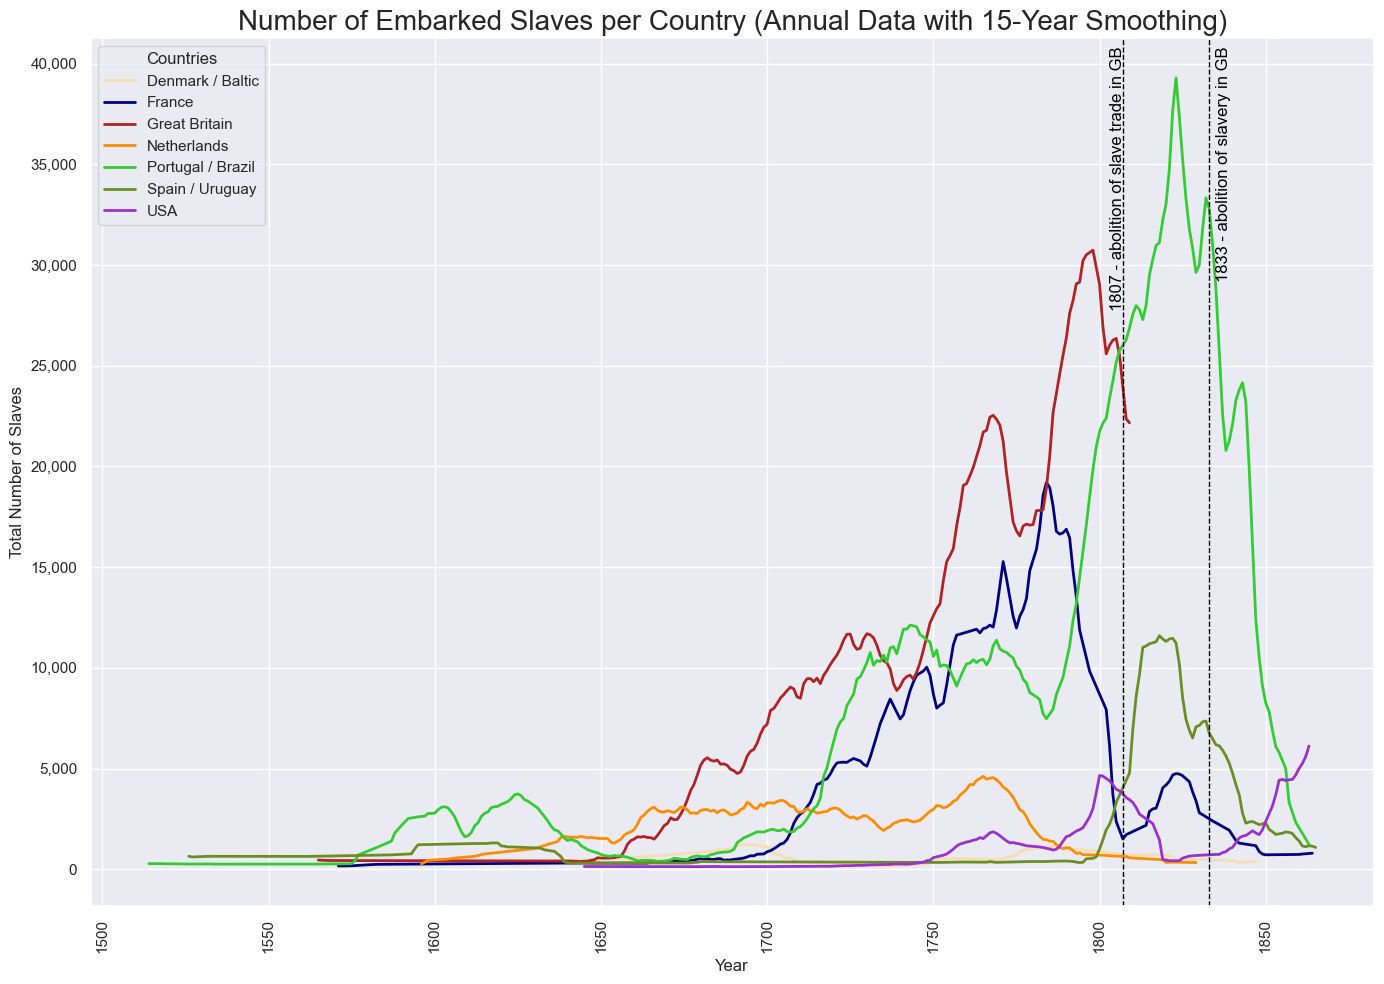

In [12]:
#plot per country

#filter data for relevant columns and years
filtered_data = gdf_all_landing_ports[['YEARAM', 'SLAMIMP', 'NATINIMP']].dropna()
filtered_data = filtered_data[filtered_data['YEARAM'].between(1500, 1870)]

#group by year and country
grouped_data = filtered_data.groupby(['YEARAM', 'NATINIMP'], as_index=False)['SLAMIMP'].sum()

#15-year smoothing
grouped_data['SLAMIMP_SMOOTH'] = grouped_data.groupby('NATINIMP')['SLAMIMP'].transform(
    lambda x: x.rolling(window=15, center=True, min_periods=1).mean()
)

#filter for selected countries
countries = ['Denmark / Baltic', 'France', 'Great Britain', 'Netherlands', 'Portugal / Brazil', 'Spain / Uruguay', 'USA']
filtered_grouped_data = grouped_data[grouped_data['NATINIMP'].isin(countries)]

#ploz
plt.figure(figsize=(14, 10))
sns.set_theme(style="darkgrid")

#colour map
palette = [color_mapping[country] for country in countries]
sns.lineplot(
    data=filtered_grouped_data,
    x='YEARAM',
    y='SLAMIMP_SMOOTH',
    hue='NATINIMP',
    palette=palette,
    hue_order=countries, 
    linewidth=2
)

#abolition events
plt.axvline(x=1807, color='black', linestyle='--', linewidth=1)
plt.text(1807 - 4, plt.ylim()[1] * 0.99, "1807 - abolition of slave trade in GB", rotation=90, color='black', va='top')

plt.axvline(x=1833, color='black', linestyle='--', linewidth=1)
plt.text(1833 + 2, plt.ylim()[1] * 0.99, "1833 - abolition of slavery in GB", rotation=90, color='black', va='top')

plt.title("Number of Embarked Slaves per Country (Annual Data with 15-Year Smoothing)", size=20)
plt.xlabel("Year")
plt.ylabel("Total Number of Slaves")
plt.legend(title='Countries')

#format y-axis with commas
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: format(int(x), ',')))

#rotate x-axis labels
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

### Q1 XXX

In [11]:
#creating geopackages for 5-year periods from 1750 to 1850

#make sure the output directory exists
output_dir = os.path.join(data_dir, "periods_5years")
os.makedirs(output_dir, exist_ok=True)

#looping through 5-year periods and saving to separate geopackages
for start_year in range(1750, 1851, 5):
    #define the end year for the 5-year period
    end_year = min(start_year + 4, 1850)

    #filter the GeoDataFrame for the current 5-year period (start_year to end_year)
    period_gdf_all_landing_ports = gdf_all_landing_ports[(gdf_all_landing_ports['YEARAM'] >= start_year) & (gdf_all_landing_ports['YEARAM'] <= end_year)].copy()
    
    #save the filtered GeoDataFrame to a new GeoPackage file if it's not empty
    if not period_gdf_all_landing_ports.empty:
        out_path = os.path.join(output_dir, f"landing_ports_{start_year}_{end_year}.gpkg")
        period_gdf_all_landing_ports.to_file(out_path, driver="GPKG")

In [12]:
period_gdf_all_landing_ports

,VOYAGEID,MJSLPTIMP,MJSLPTIMP_lng,MJSLPTIMP_lat,YEARAM,SLAMIMP,NATINIMP,geometry
2561,3842,Rio de Janeiro province,-43.57,-23.02,1850,390.0,nan,POINT (-43.57 -23.02)
2562,3843,Rio de Janeiro province,-43.57,-23.02,1850,731.0,Portugal / Brazil,POINT (-43.57 -23.02)
2563,3844,Santos,-46.33333,-23.95,1850,500.0,USA,POINT (-46.33333 -23.95)
2564,3845,"Rio de Janeiro, Sao Paulo, Santa Catarina",-45.99,-23.79,1850,539.0,nan,POINT (-45.99 -23.79)
2675,4013,Freetown,-13.23,8.49,1850,151.0,Portugal / Brazil,POINT (-13.23 8.49)
...,...,...,...,...,...,...,...,...
3082,4777,"Bahia, port unspecified",-38.51083,-12.97111,1850,460.0,Portugal / Brazil,POINT (-38.51083 -12.97111)
3084,4783,Rio de Janeiro province,-43.57,-23.02,1850,291.0,nan,POINT (-43.57 -23.02)
3088,4790,Santos,-46.33333,-23.95,1850,817.0,nan,POINT (-46.33333 -23.95)
15117,39045,"Cuba, south coast",-75.73811,19.95076,1850,180.0,Spain / Uruguay,POINT (-75.73811 19.95076)


In [13]:
#reproject basemap and ports to EPSG:4326 for plotting with lat/lon axes
land_4326 = land_3857.to_crs("EPSG:4326")
ocean_4326 = ocean_3857.to_crs("EPSG:4326")
rivers_4326 = rivers_3857.to_crs("EPSG:4326")
gdf_all_landing_ports_4326 = gdf_all_landing_ports

#calculate lon/lat from point geometry
gdf_all_landing_ports_4326["lon"] = gdf_all_landing_ports_4326.geometry.x
gdf_all_landing_ports_4326["lat"] = gdf_all_landing_ports_4326.geometry.y

In [14]:
#bounding box for map
americas_bbox_4326 = (-100, -30, 0, 40)
americas_data_bbox_4326 = (-100, -30, -50, 50)

#filter for ports in the americas
gdf_americas_landing_ports_4326 = gdf_all_landing_ports_4326[
    (gdf_all_landing_ports_4326["lon"] >= americas_data_bbox_4326[0]) &
    (gdf_all_landing_ports_4326["lon"] <= americas_data_bbox_4326[1]) &
    (gdf_all_landing_ports_4326["lat"] >= americas_data_bbox_4326[2]) &
    (gdf_all_landing_ports_4326["lat"] <= americas_data_bbox_4326[3])
].copy()

In [ ]:
#filter years of interest (1750 to 1850)
years = range(1750, 1851)

#figure size and image resolution
target_width = 1440   # pixels
target_height = 1080  # pixels
dpi = 150
figsize = (target_width / dpi, target_height / dpi)

#for every year create a heatmap with plotting every point with transparency
for year in years:

    #gdf of year
    yearly_gdf_american_landing_ports = gdf_americas_landing_ports_4326[gdf_americas_landing_ports_4326['YEARAM'] == year]

    if not yearly_gdf_american_landing_ports.empty:
        fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

        #plot basemap filtered to bounding box
        americas_land = land_4326.cx[americas_bbox_4326[0]:americas_bbox_4326[2], americas_bbox_4326[1]:americas_bbox_4326[3]]
        americas_ocean = ocean_4326.cx[americas_bbox_4326[0]:americas_bbox_4326[2], americas_bbox_4326[1]:americas_bbox_4326[3]]
        americas_rivers = rivers_4326.cx[americas_bbox_4326[0]:americas_bbox_4326[2], americas_bbox_4326[1]:americas_bbox_4326[3]]
        americas_land.plot(ax=ax, color='#fff5e1', edgecolor='black')
        americas_ocean.plot(ax=ax, color='#d3f2ff', edgecolor='none')
        americas_rivers.plot(ax=ax, color='#4f7bfe', edgecolor='none', alpha=0.6, linewidth=0.4)

        #plot landing ports with transparency
        yearly_gdf_american_landing_ports.plot(ax=ax, marker='o', color='red', alpha=0.3, markersize=20)

        #limit to bounding box
        ax.set_xlim([americas_bbox_4326[0], americas_bbox_4326[2]])
        ax.set_ylim([americas_bbox_4326[1], americas_bbox_4326[3]])

        ax.set_aspect('auto')
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        ax.set_title(f"Heatmap for {year}", pad=20)
        ax.grid(True, which='both', color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
        fig.set_size_inches(figsize)
        
        fig.savefig(
            f"{save_dir}/heatmap/1750to1850/heatmap_{year}.jpg",
            dpi=dpi
        )
        plt.close(fig)
        #fig.show()
        #break

-> not needed??

unten -> check if correct!!!!!!!!

Distortion values:
1 : 433.25818940704
2 : 71.54813339926639
3 : 36.34096510559298
4 : 30.46297563593583
5 : 26.773406496901288
6 : 18.84502461778921
7 : 11.576063108354003
8 : 6.509332640778437
9 : 6.087193569854836


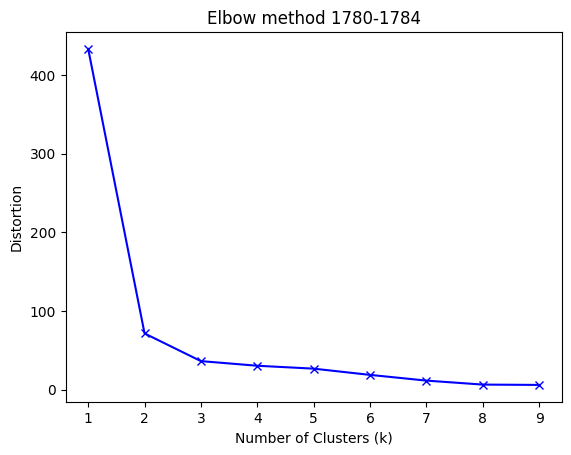

In [14]:
#elbow method for kmeans
#https://www.geeksforgeeks.org/machine-learning/elbow-method-for-optimal-value-of-k-in-kmeans/ (13.09.2025)

distortions = []
inertias = []
mapping1 = {}
mapping2 = {}
K = range(1, 10)
X=gdf_americas_landing_ports_4326[(gdf_americas_landing_ports_4326['YEARAM'] >= 1780) & (gdf_americas_landing_ports_4326['YEARAM'] <= 1784)][['lon', 'lat']]

for k in K:
    kmeanModel = KMeans(n_clusters=k, random_state=42).fit(X)
    
    distortions.append(sum(np.min(cdist(X, kmeanModel.cluster_centers_, 'euclidean'), axis=1)**2) / X.shape[0])
    
    inertias.append(kmeanModel.inertia_)
    
    mapping1[k] = distortions[-1]
    mapping2[k] = inertias[-1]

print("Distortion values:")
for key, val in mapping1.items():
    print(f'{key} : {val}')

plt.plot(K, distortions, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Distortion')
plt.title('Elbow method 1780-1784')
plt.show()

In [84]:
#kmeans clustering based on YEARAM

#filter for YEARAM in 1750 to 1850
gdf_americas_landing_ports_4326_filtered = gdf_americas_landing_ports_4326[(gdf_americas_landing_ports_4326['YEARAM'] >= 1750) & (gdf_americas_landing_ports_4326['YEARAM'] <= 1850)].copy()

#use the most common YEARAM per VOYAGEID in this period
features = []
for voyage in gdf_americas_landing_ports_4326_filtered['VOYAGEID'].unique():
    sub = gdf_americas_landing_ports_4326_filtered[gdf_americas_landing_ports_4326_filtered['VOYAGEID'] == voyage]
    yearam = sub['YEARAM'].mode().iloc[0] if not sub['YEARAM'].mode().empty else -1
    features.append([voyage, yearam])

features_df = pd.DataFrame(features, columns=['VOYAGEID', 'YEARAM'])

#standardize YEARAM
X = features_df[['YEARAM']].values
X = StandardScaler().fit_transform(X)

#kMeans clustering
kmeans = KMeans(n_clusters=4, random_state=0)
features_df['kmeans_cluster'] = kmeans.fit_predict(X)

#merge clusters back to a gdf for plotting (using first geometry per VOYAGEID)
geometry = []
for voyage in features_df['VOYAGEID']:
    geom = gdf_americas_landing_ports_4326_filtered[gdf_americas_landing_ports_4326_filtered['VOYAGEID'] == voyage].geometry.iloc[0]
    geometry.append(geom)
features_df['geometry'] = geometry
cluster_gdf_all_landing_ports = gpd.GeoDataFrame(features_df, geometry='geometry')

#cluster colours
cluster_colours = ['#e41a1c', '#377eb8', '#4daf4a', '#ff7f00']

#sort clusters by mean year (ascending)
cluster_mean_df = cluster_gdf_all_landing_ports.groupby('kmeans_cluster')['YEARAM'].mean().sort_values().reset_index()
cluster_order = cluster_mean_df['kmeans_cluster'].tolist()

#remap cluster numbers to new order
cluster_map = {old: new for new, old in enumerate(cluster_order)}
cluster_gdf_all_landing_ports['cluster_sorted'] = cluster_gdf_all_landing_ports['kmeans_cluster'].map(cluster_map)

#recalculate means for sorted clusters
sorted_cluster_means = cluster_gdf_all_landing_ports.groupby('cluster_sorted')['YEARAM'].mean().round(0).astype(int)
sorted_legend_labels = [
    f'Cluster {i} (mean: {mean})'
    for i, mean in sorted_cluster_means.items()
]

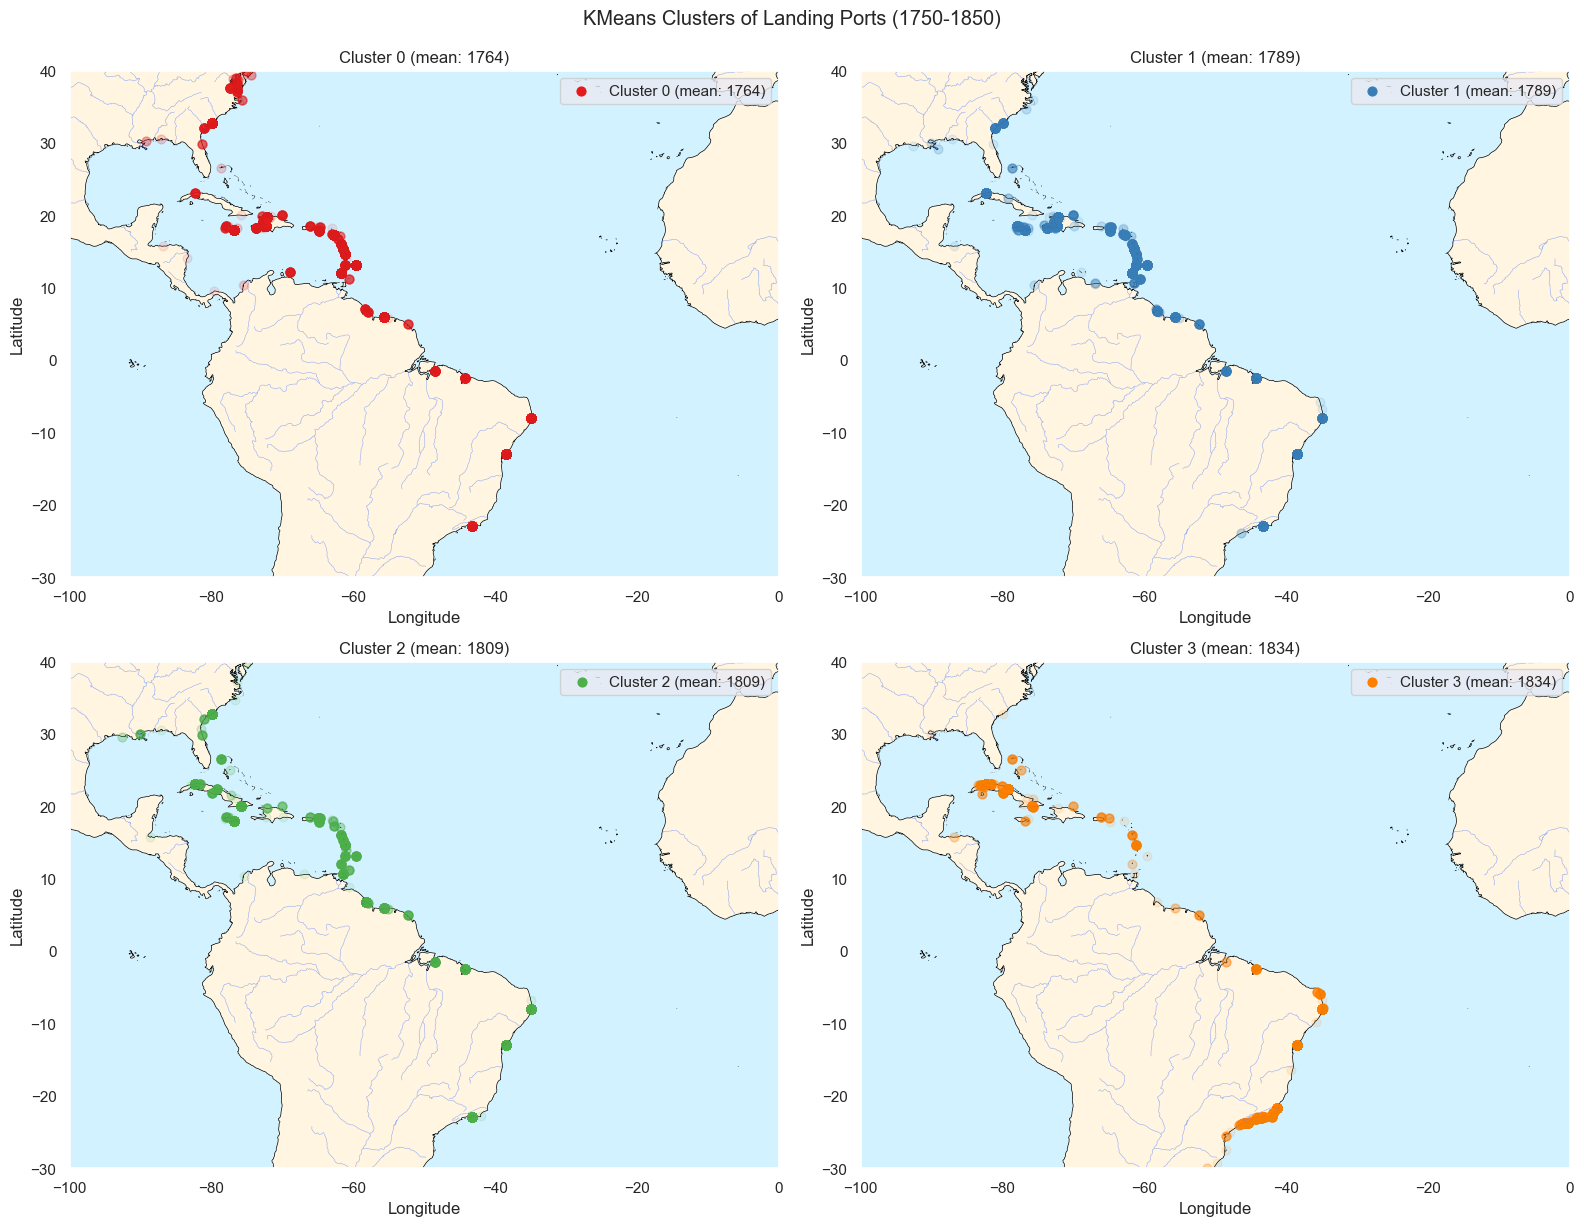

In [178]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, color in enumerate(cluster_colours):
    ax = axes[i]
    subset = cluster_gdf_all_landing_ports[cluster_gdf_all_landing_ports['cluster_sorted'] == i]
    # Plot basemap
    land_4326.plot(ax=ax, color='#fff5e1', edgecolor='black')
    ocean_4326.plot(ax=ax, color='#d3f2ff', edgecolor='none')
    rivers_4326.plot(ax=ax, color='#4f7bfe', edgecolor='none', alpha=0.6, linewidth=0.4)
    # Plot cluster points
    scatter = ax.scatter(
        subset['geometry'].x,
        subset['geometry'].y,
        color=color,
        alpha=0.1,
        s=40
    )
    # Add legend entry with full color (no transparency)
    ax.scatter([], [], color=color, alpha=1.0, s=40, label=sorted_legend_labels[i])
    ax.set_xlim([americas_bbox_4326[0], americas_bbox_4326[2]])
    ax.set_ylim([americas_bbox_4326[1], americas_bbox_4326[3]])
    ax.grid(True, which='both', color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
    ax.set_title(sorted_legend_labels[i])
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.legend()


plt.tight_layout()
fig.suptitle('KMeans Clusters of Landing Ports (1750-1850)', y=1.02)
plt.show()

In [86]:
print('cluster 0: '+str(round(cluster_gdf_all_landing_ports[cluster_gdf_all_landing_ports['kmeans_cluster'] == 0]['YEARAM'].mean(),0)))
print('cluster 1: '+str(round(cluster_gdf_all_landing_ports[cluster_gdf_all_landing_ports['kmeans_cluster'] == 1]['YEARAM'].mean(),0)))
print('cluster 2: '+str(round(cluster_gdf_all_landing_ports[cluster_gdf_all_landing_ports['kmeans_cluster'] == 2]['YEARAM'].mean(),0)))
print('cluster 3: '+str(round(cluster_gdf_all_landing_ports[cluster_gdf_all_landing_ports['kmeans_cluster'] == 3]['YEARAM'].mean(),0)))

cluster 0: 1809.0
cluster 1: 1764.0
cluster 2: 1834.0
cluster 3: 1789.0


In [ ]:
#aggregate files from k-means clustering (in QGIS) for visualisation

clustering_dir = os.path.join(data_dir, "clustering_kmeans4")
out_dir = os.path.join(clustering_dir, "contracted")
os.makedirs(out_dir, exist_ok=True)

for fname in os.listdir(clustering_dir):
    if fname.endswith(".gpkg"):
        fpath = os.path.join(clustering_dir, fname)
        gdf = gpd.read_file(fpath)
        #group by MJSLPTIMP and CLUSTER_ID, aggregate geometry and count
        grouped = (
            gdf.groupby(['MJSLPTIMP', 'CLUSTER_ID'])
            .agg({
                'geometry': 'first',
            })
            .reset_index()
        )
        grouped['count'] = gdf.groupby(['MJSLPTIMP', 'CLUSTER_ID']).size().values
        grouped_gdf = gpd.GeoDataFrame(grouped, geometry='geometry', crs=gdf.crs)
        out_path = os.path.join(out_dir, f"contracted_{fname}")
        grouped_gdf.to_file(out_path, driver="GPKG")
        print(f"Saved: {out_path}")

Saved: ../data/clustering_kmeans4\contracted\contracted_kmeans4_1750_1754.gpkg
Saved: ../data/clustering_kmeans4\contracted\contracted_kmeans4_1755_1759.gpkg
Saved: ../data/clustering_kmeans4\contracted\contracted_kmeans4_1760_1764.gpkg
Saved: ../data/clustering_kmeans4\contracted\contracted_kmeans4_1765_1769.gpkg
Saved: ../data/clustering_kmeans4\contracted\contracted_kmeans4_1770_1774.gpkg
Saved: ../data/clustering_kmeans4\contracted\contracted_kmeans4_1775_1779.gpkg
Saved: ../data/clustering_kmeans4\contracted\contracted_kmeans4_1780_1784.gpkg
Saved: ../data/clustering_kmeans4\contracted\contracted_kmeans4_1785_1789.gpkg
Saved: ../data/clustering_kmeans4\contracted\contracted_kmeans4_1790_1794.gpkg
Saved: ../data/clustering_kmeans4\contracted\contracted_kmeans4_1795_1799.gpkg
Saved: ../data/clustering_kmeans4\contracted\contracted_kmeans4_1800_1804.gpkg
Saved: ../data/clustering_kmeans4\contracted\contracted_kmeans4_1805_1809.gpkg
Saved: ../data/clustering_kmeans4\contracted\contrac

### Q2 TITLE

In [15]:
#exporting all journeys to british colonies from 1700 to 1900 as a geopackage-file

#list for journeys to british colonies
filtered_journeys = []

#loop for every year from 1700 to 1900
for year in range(1700, 1901):
    shp_path = os.path.join(colonies_dir+"yearly_shapefiles", f"colonies_{year}.gpkg")
    if not os.path.exists(shp_path):
        continue

    #load the yearly colonies shapefile
    colonies_gdf_all_landing_ports = gpd.read_file(shp_path)

    #filter for British colonies
    british = colonies_gdf_all_landing_ports[
        colonies_gdf_all_landing_ports['colonizer_grouped'].str.lower().isin(['british', 'united kingdom'])
    ]
    british = british[british.geometry.notnull()]
    if british.empty:
        continue

    #filter journeys for this year
    journeys_this_year = gdf_all_landing_ports_4326[gdf_all_landing_ports_4326['YEARAM'] == year].copy()
    if journeys_this_year.empty:
        continue

    #spatial join
    #keep only journeys whose destination is within a British colony polygon
    joined = gpd.sjoin(
        journeys_this_year.set_geometry('geometry'),
        british[['geometry']],
        how='inner',
        predicate='within'
    )
    if not joined.empty:
        filtered_journeys.append(joined)

# Concatenate all filtered journeys into a single GeoDataFrame
if filtered_journeys:
    british_journeys_gdf_all_landing_ports = gpd.GeoDataFrame(pd.concat(filtered_journeys, ignore_index=True), crs=gdf_all_landing_ports.crs)
else:
    british_journeys_gdf_all_landing_ports = gpd.GeoDataFrame(columns=gdf_all_landing_ports.columns, crs=gdf_all_landing_ports.crs)

#export all journeys to British colonies as a single geopackage-file
output_path = data_dir+"to_british_colonies/to_british_colonies_1700to1900.gpkg"
os.makedirs(os.path.dirname(output_path), exist_ok=True)
british_journeys_gdf_all_landing_ports.to_file(output_path, driver="GPKG")
print(f"Exported to {output_path}")

Exported to ../data/to_british_colonies/to_british_colonies_1700to1900.gpkg


In [8]:
color_mapping

{'Denmark / Baltic': 'wheat',
 'France': 'navy',
 'Great Britain': 'firebrick',
 'Netherlands': 'darkorange',
 'Portugal / Brazil': 'limegreen',
 'Spain / Uruguay': 'olivedrab',
 'USA': 'darkorchid',
 'Other': 'grey'}

In [16]:
#dataframe for the following calculations
slave_voyages_toGB = british_journeys_gdf_all_landing_ports

#drop missing values in relevant columns and ensure YEARAM is integer
slave_voyages_toGB = slave_voyages_toGB.dropna(subset=['YEARAM', 'SLAMIMP', 'NATINIMP'])
slave_voyages_toGB['YEARAM'] = slave_voyages_toGB['YEARAM'].astype(int)

#group by country and year
sv_grouped = slave_voyages_toGB.groupby(['NATINIMP', 'YEARAM'], as_index=False)['SLAMIMP'].sum()

#filter selected countries
countries = ["Great Britain", "France", "Netherlands", "USA", "Spain / Uruguay", "Portugal / Brazil"]
#countries = ["France", "Netherlands", "USA", "Spain / Uruguay", "Portugal / Brazil"]
sv_grouped_filtered = sv_grouped[sv_grouped['NATINIMP'].isin(countries)]

sv_grouped_filtered_sm = sv_grouped_filtered
sv_grouped_filtered_START = sv_grouped_filtered

c:\Users\andre\AppData\Local\Programs\Python\Python313\Lib\site-packages\geopandas\geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


C:\Users\andre\AppData\Local\Temp\ipykernel_15556\3866716748.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sv_grouped_filtered_sm['SLAMIMP_SMOOTH'] = (


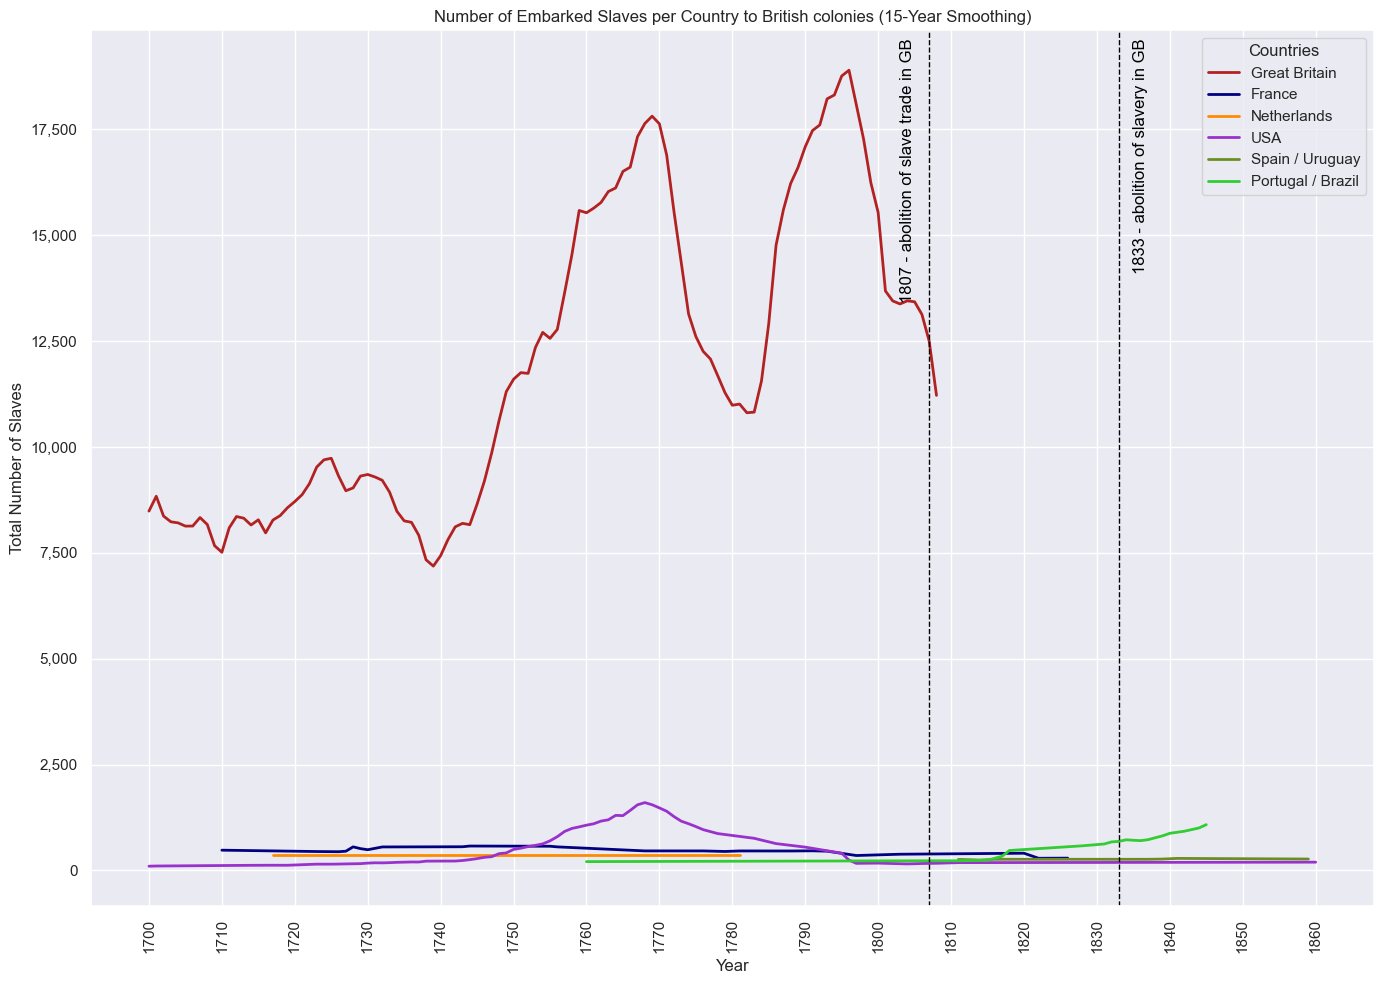

In [17]:
#embareked slaves per country to british colonies

#apply 15-year smoothing
sv_grouped_filtered_sm['SLAMIMP_SMOOTH'] = (
    sv_grouped_filtered
    .groupby('NATINIMP')['SLAMIMP']
    .transform(lambda x: x.rolling(window=15, center=True, min_periods=1).mean())
)

#plotting
plt.figure(figsize=(14, 10))
sns.set_theme(style="darkgrid")

palette = [color_mapping[country] for country in countries if country in color_mapping]
hue_order = countries

sns.lineplot(
    data=sv_grouped_filtered_sm,
    x='YEARAM',
    y='SLAMIMP_SMOOTH',
    hue='NATINIMP',
    palette=palette,
    hue_order=hue_order,
    linewidth=2
)

#vertical lines for 1807 and 1833
plt.axvline(x=1807, color='black', linestyle='--', linewidth=1)
plt.text(1807 - 4, plt.ylim()[1] * 0.99, "1807 - abolition of slave trade in GB", rotation=90, color='black', va='top')

plt.axvline(x=1833, color='black', linestyle='--', linewidth=1)
plt.text(1833 + 2, plt.ylim()[1] * 0.99, "1833 - abolition of slavery in GB", rotation=90, color='black', va='top')

plt.title("Number of Embarked Slaves per Country to British colonies (15-Year Smoothing)")
plt.xlabel("Year")
plt.ylabel("Total Number of Slaves")
plt.legend(title='Countries')

plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: format(int(x), ',')))

plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(10))
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

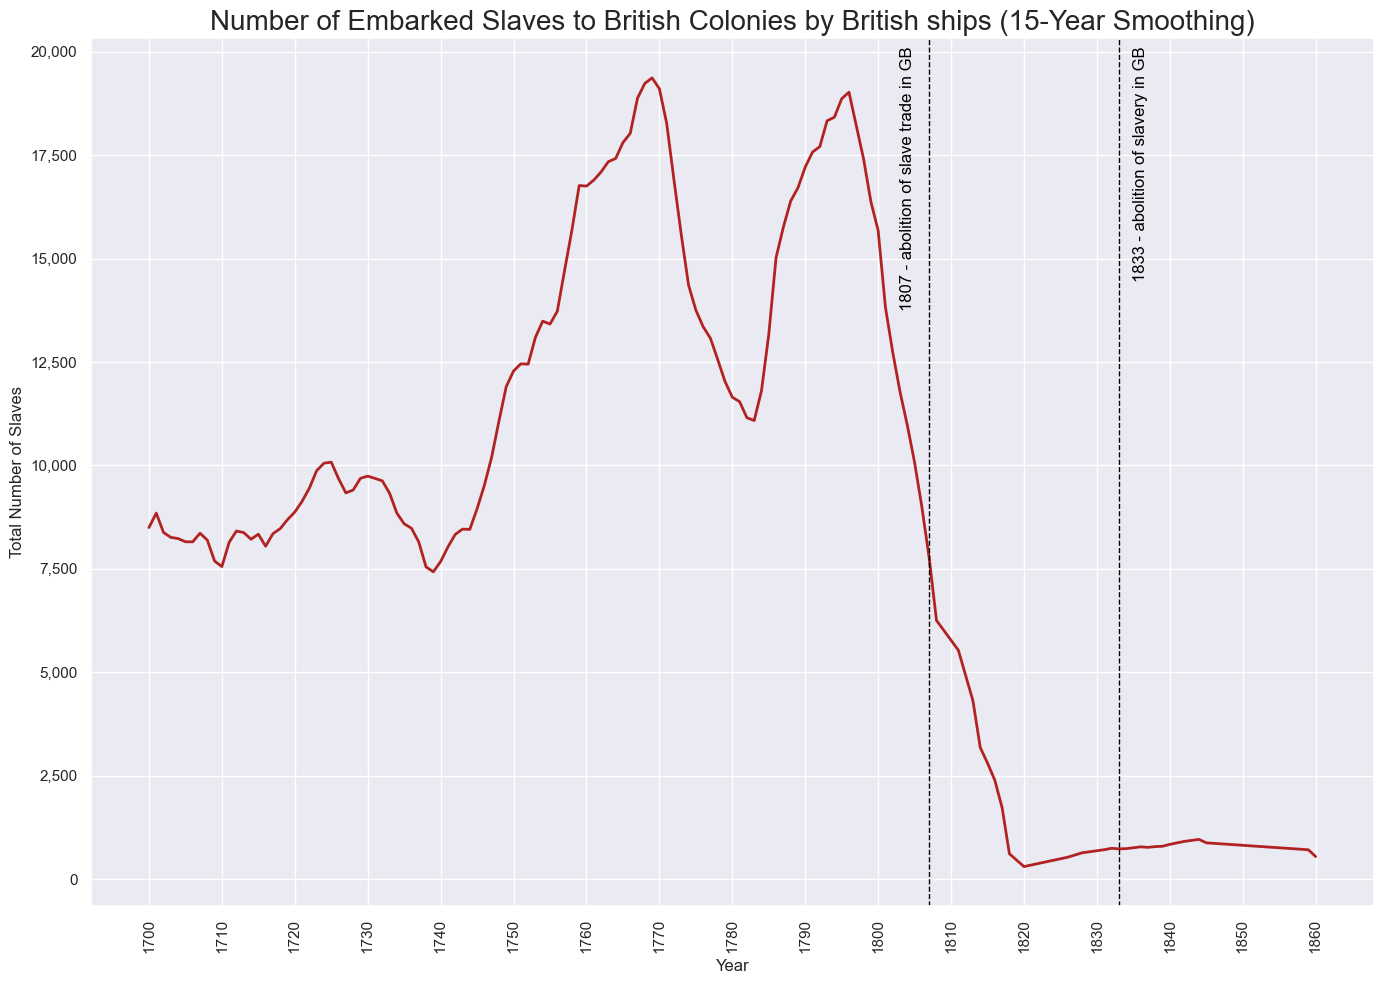

In [18]:
#only GB

#group by year
sv_grouped = sv_grouped_filtered_START.groupby('YEARAM', as_index=False)['SLAMIMP'].sum()

#15-year smoothing
sv_grouped['SLAMIMP_SMOOTH'] = (
    sv_grouped['SLAMIMP']
    .rolling(window=15, center=True, min_periods=1)
    .mean()
)

#plotting
plt.figure(figsize=(14, 10))
sns.set_theme(style="darkgrid")

sns.lineplot(
    data=sv_grouped,
    x='YEARAM',
    y='SLAMIMP_SMOOTH',
    color='firebrick',
    linewidth=2
)

# Add vertical lines for 1807 and 1833
plt.axvline(x=1807, color='black', linestyle='--', linewidth=1)
plt.text(1807 - 4, plt.ylim()[1] * 0.99, "1807 - abolition of slave trade in GB", rotation=90, color='black', va='top')

plt.axvline(x=1833, color='black', linestyle='--', linewidth=1)
plt.text(1833 + 2, plt.ylim()[1] * 0.99, "1833 - abolition of slavery in GB", rotation=90, color='black', va='top')

plt.title("Number of Embarked Slaves to British Colonies by British ships (15-Year Smoothing)", size=20)
plt.xlabel("Year")
plt.ylabel("Total Number of Slaves")

plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: format(int(x), ',')))

plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(10))
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

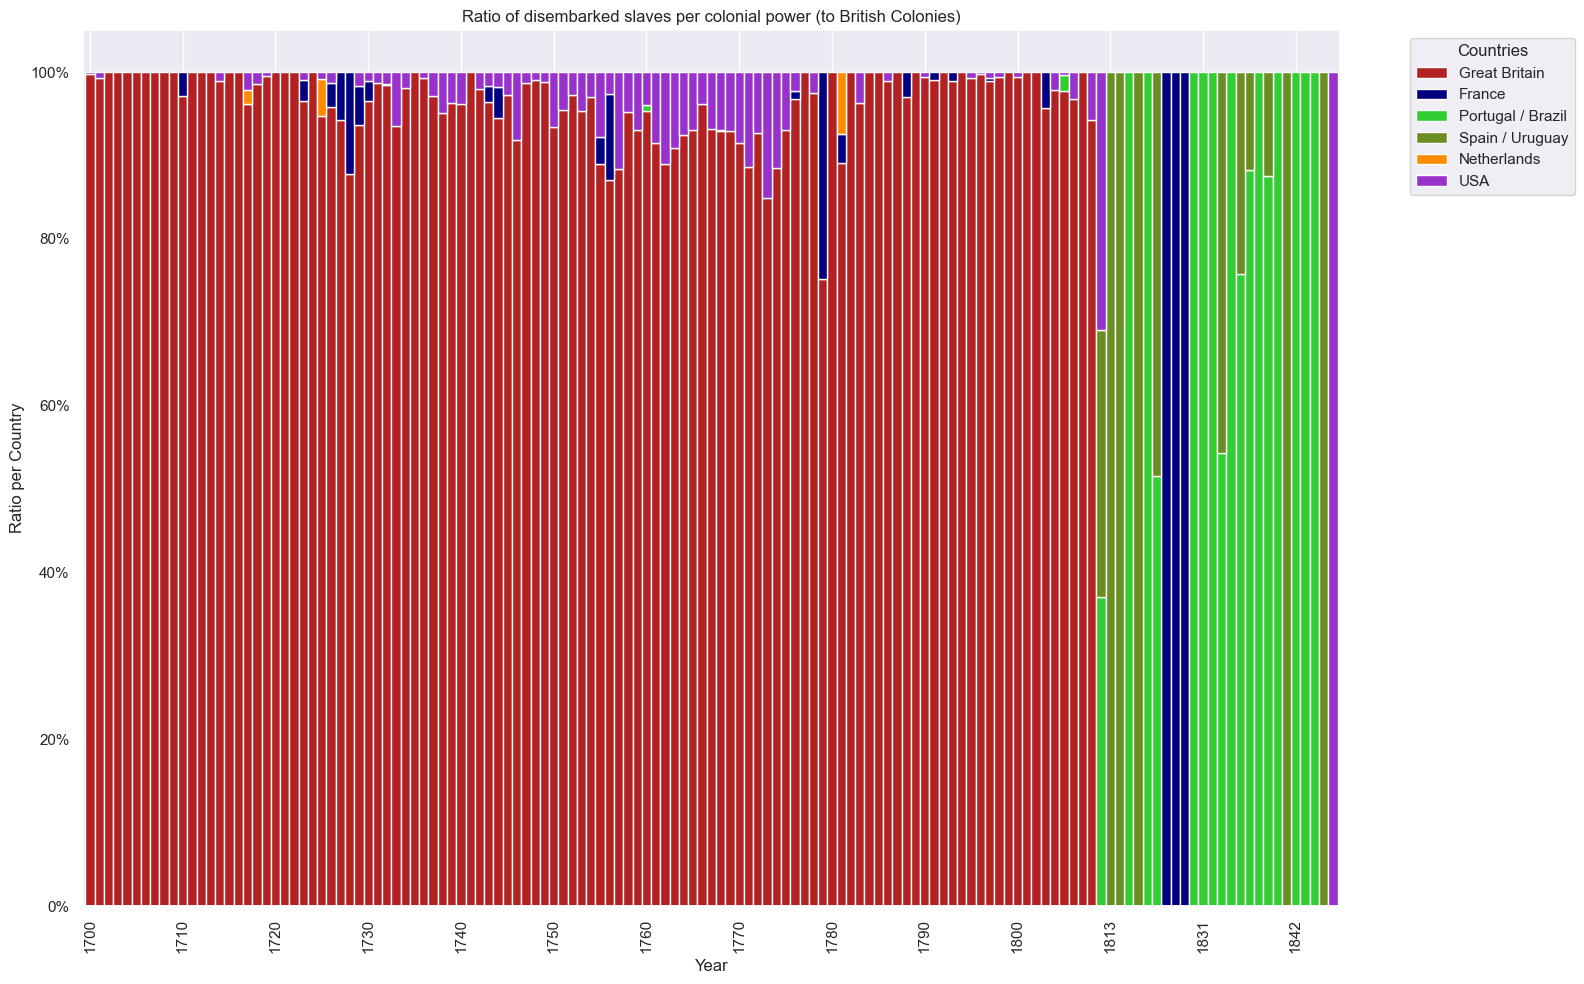

In [19]:
#as stacked bars (relative)

#group by country and year
sv_grouped = sv_grouped_filtered_START.groupby(['NATINIMP', 'YEARAM'], as_index=False)['SLAMIMP'].sum()

#desired order
country_order = [
    "Great Britain",
    "France",
    "Portugal / Brazil",
    "Spain / Uruguay",
    "Netherlands",
    "USA"
]
color_order = [
    color_mapping["Great Britain"],
    color_mapping["France"],
    color_mapping["Portugal / Brazil"],
    color_mapping["Spain / Uruguay"],
    color_mapping["Netherlands"],
    color_mapping["USA"]
]

#filter selected countries and enforce order
sv_grouped_filtered = sv_grouped[sv_grouped['NATINIMP'].isin(country_order)]
sv_grouped_filtered['NATINIMP'] = pd.Categorical(sv_grouped_filtered['NATINIMP'], categories=country_order, ordered=True)

#calculate total per year
total_per_year = sv_grouped_filtered.groupby('YEARAM')['SLAMIMP'].sum().reset_index().rename(columns={'SLAMIMP': 'TOTAL_SLAMIMP'})

#merge to get total per year for each row
sv_grouped_filtered = sv_grouped_filtered.merge(total_per_year, on='YEARAM', how='left')

#calculate ratio
sv_grouped_filtered['RATIO'] = sv_grouped_filtered['SLAMIMP'] / sv_grouped_filtered['TOTAL_SLAMIMP']

#pivot for barplot (years as index, countries as columns, correct order)
pivot_df = sv_grouped_filtered.pivot(index='YEARAM', columns='NATINIMP', values='RATIO').fillna(0)
pivot_df = pivot_df[country_order]  # enforce column order

#plotting
plt.figure(figsize=(16, 10))
pivot_df.plot(kind='bar', stacked=True, color=color_order, width=1.0, ax=plt.gca())

plt.title("Ratio of disembarked slaves per colonial power (to British Colonies)")
plt.xlabel("Year")
plt.ylabel("Ratio per Country")
plt.legend(title='Countries', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.xticks(ticks=range(0, len(pivot_df.index), 10), labels=pivot_df.index[::10], rotation=90)
plt.tight_layout()
plt.show()

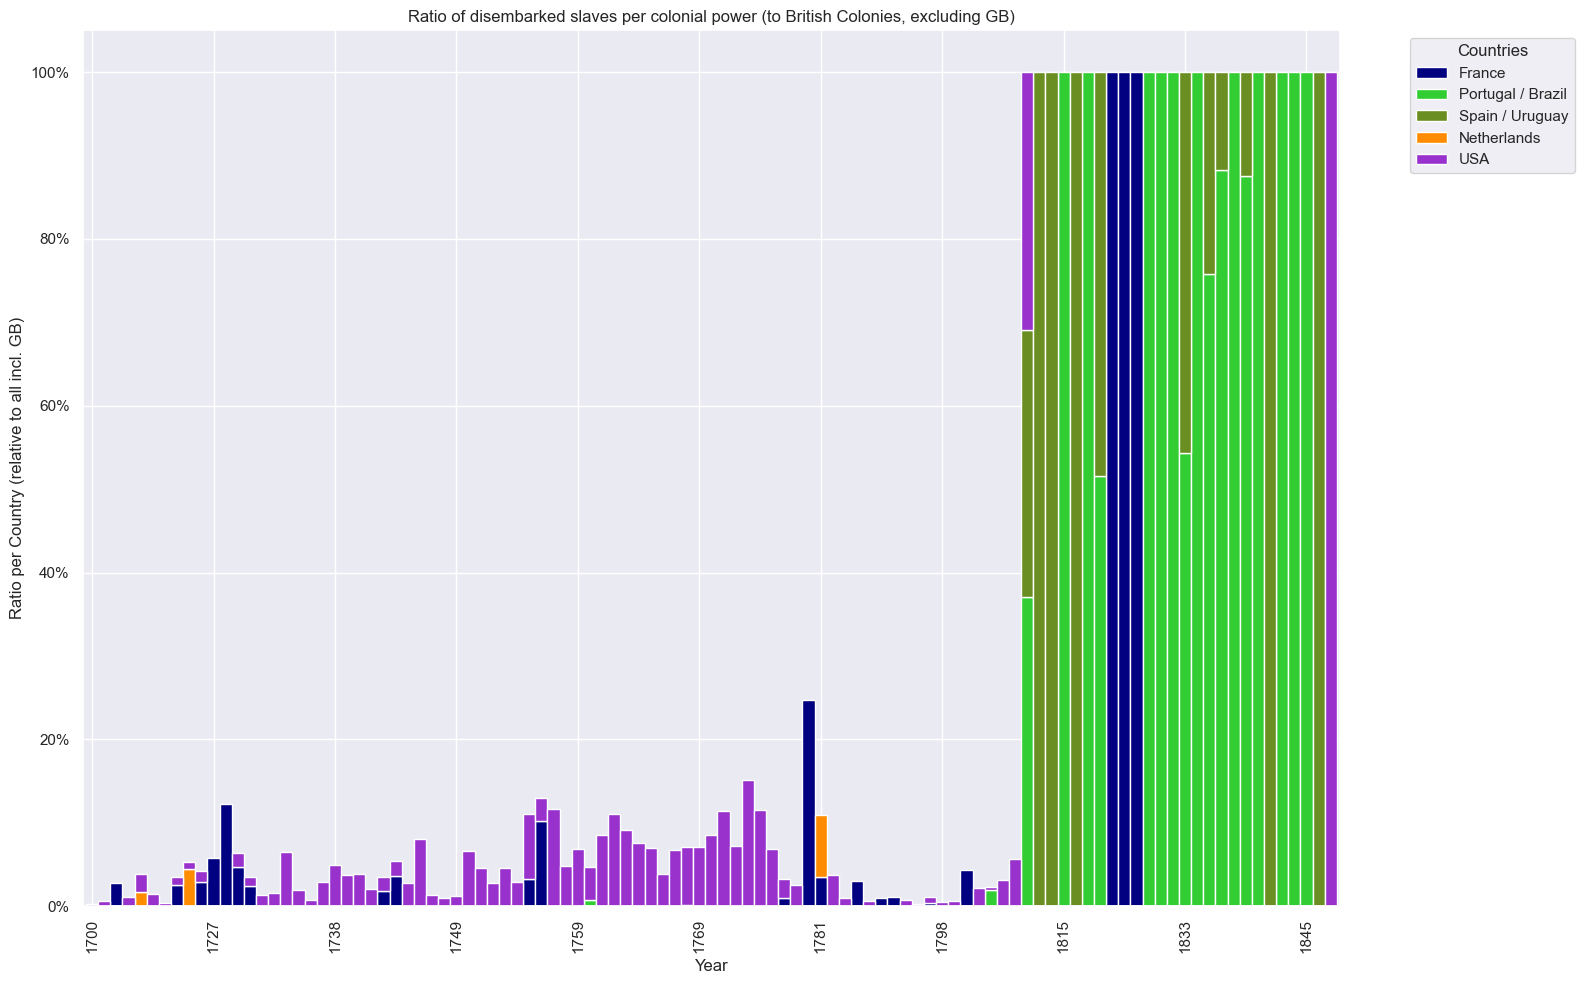

In [20]:
#as stacked bars excluding GB (relative to all)

#group by country and year
sv_grouped = sv_grouped_filtered_START.groupby(['NATINIMP', 'YEARAM'], as_index=False)['SLAMIMP'].sum()

#define all countries for ratio calculation (including GB)
all_countries = [
    "Great Britain",
    "France",
    "Portugal / Brazil",
    "Spain / Uruguay",
    "Netherlands",
    "USA"
]
#only show these (without GB)
country_order = [
    "France",
    "Portugal / Brazil",
    "Spain / Uruguay",
    "Netherlands",
    "USA"
]
color_order = [
    color_mapping["France"],
    color_mapping["Portugal / Brazil"],
    color_mapping["Spain / Uruguay"],
    color_mapping["Netherlands"],
    color_mapping["USA"]
]

#calculate total per year (including GB)
total_per_year = (
    sv_grouped[sv_grouped['NATINIMP'].isin(all_countries)]
    .groupby('YEARAM')['SLAMIMP']
    .sum()
    .reset_index()
    .rename(columns={'SLAMIMP': 'TOTAL_SLAMIMP'})
)

#filter only countries to show, but use total including GB for ratio
sv_grouped_filtered = sv_grouped[sv_grouped['NATINIMP'].isin(country_order)].copy()
sv_grouped_filtered['NATINIMP'] = pd.Categorical(sv_grouped_filtered['NATINIMP'], categories=country_order, ordered=True)
sv_grouped_filtered = sv_grouped_filtered.merge(total_per_year, on='YEARAM', how='left')
sv_grouped_filtered['RATIO'] = sv_grouped_filtered['SLAMIMP'] / sv_grouped_filtered['TOTAL_SLAMIMP']

#pivot for barplot (years as index, countries as columns, correct order)
pivot_df = sv_grouped_filtered.pivot(index='YEARAM', columns='NATINIMP', values='RATIO').fillna(0)
pivot_df = pivot_df[country_order]  # enforce column order

#plotting
plt.figure(figsize=(16, 10))
pivot_df.plot(kind='bar', stacked=True, color=color_order, width=1.0, ax=plt.gca())

plt.title("Ratio of disembarked slaves per colonial power (to British Colonies, excluding GB)")
plt.xlabel("Year")
plt.ylabel("Ratio per Country (relative to all incl. GB)")
plt.legend(title='Countries', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.xticks(ticks=range(0, len(pivot_df.index), 10), labels=pivot_df.index[::10], rotation=90)
plt.tight_layout()
plt.show()

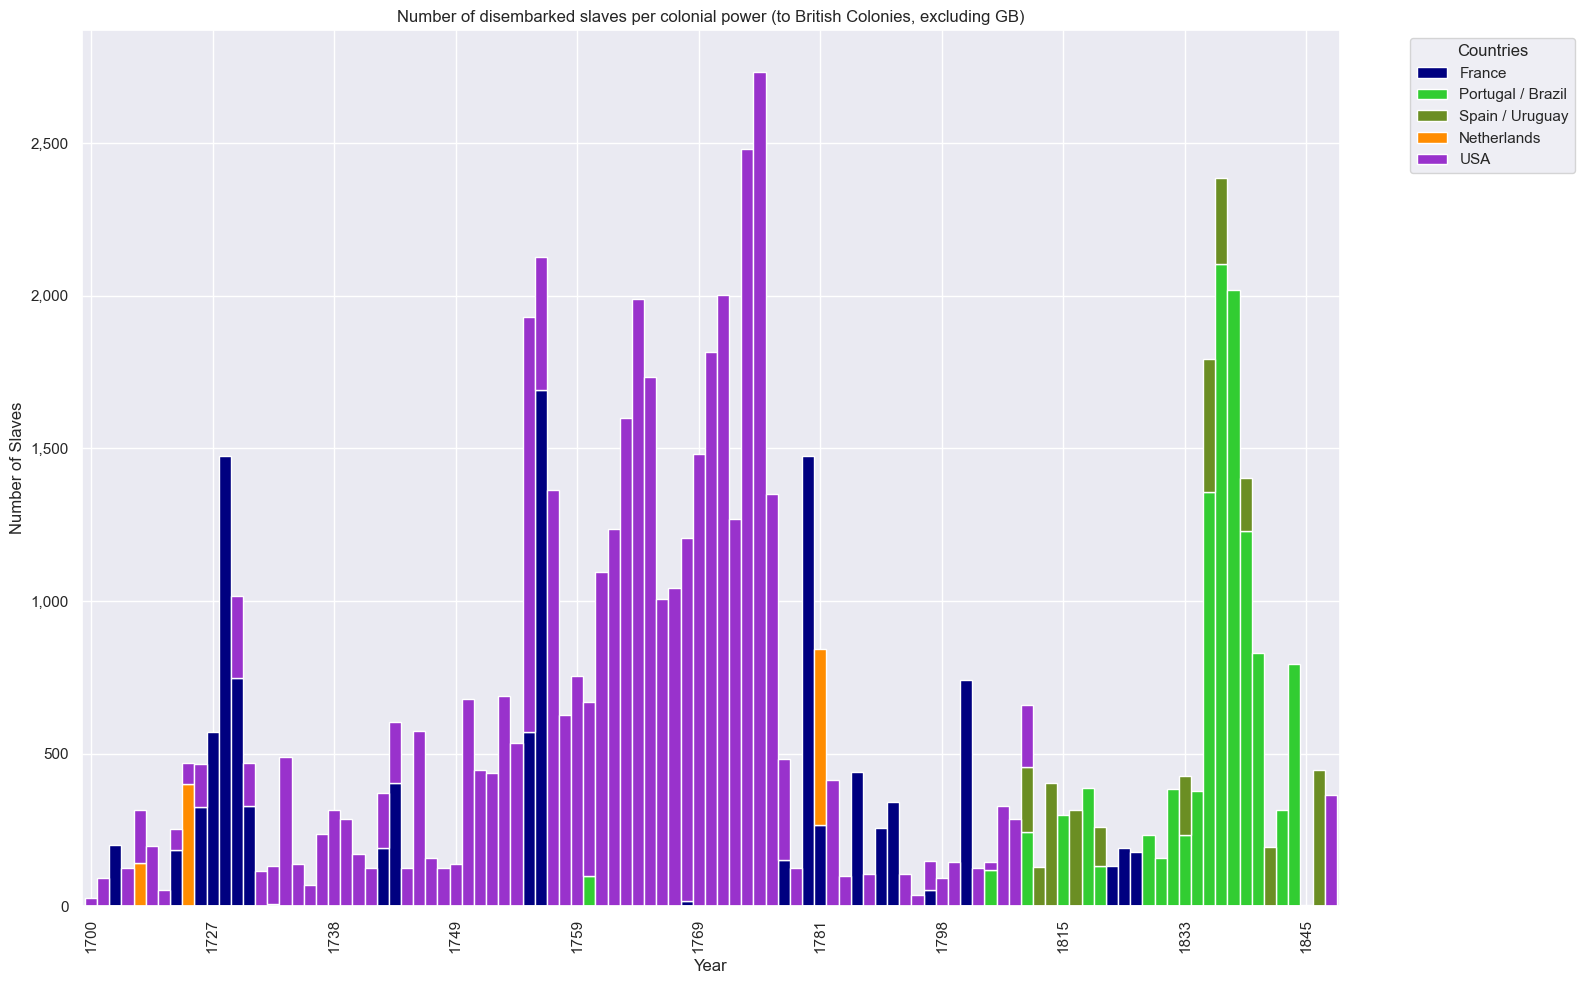

In [21]:
#total number of slaves per year excluding GB

#group by country and year
sv_grouped = sv_grouped_filtered_START.groupby(['NATINIMP', 'YEARAM'], as_index=False)['SLAMIMP'].sum()

#define all countries for ratio calculation (including GB)
all_countries = [
    "Great Britain",
    "France",
    "Portugal / Brazil",
    "Spain / Uruguay",
    "Netherlands",
    "USA"
]
#only show these (without GB)
country_order = [
    "France",
    "Portugal / Brazil",
    "Spain / Uruguay",
    "Netherlands",
    "USA"
]
color_order = [
    color_mapping["France"],
    color_mapping["Portugal / Brazil"],
    color_mapping["Spain / Uruguay"],
    color_mapping["Netherlands"],
    color_mapping["USA"]
]

#filter only countries to show
sv_grouped_filtered = sv_grouped[sv_grouped['NATINIMP'].isin(country_order)].copy()
sv_grouped_filtered['NATINIMP'] = pd.Categorical(sv_grouped_filtered['NATINIMP'], categories=country_order, ordered=True)

#pivot for barplot (years as index, countries as columns, correct order)
pivot_df = sv_grouped_filtered.pivot(index='YEARAM', columns='NATINIMP', values='SLAMIMP').fillna(0)
pivot_df = pivot_df[country_order]  # enforce column order

#plot as stacked bar chart (absolute numbers)
plt.figure(figsize=(16, 10))
pivot_df.plot(kind='bar', stacked=True, color=color_order, width=1.0, ax=plt.gca())

plt.title("Number of disembarked slaves per colonial power (to British Colonies, excluding GB)")
plt.xlabel("Year")
plt.ylabel("Number of Slaves")
plt.legend(title='Countries', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: format(int(x), ',')))
plt.xticks(ticks=range(0, len(pivot_df.index), 10), labels=pivot_df.index[::10], rotation=90)
plt.tight_layout()
plt.show()

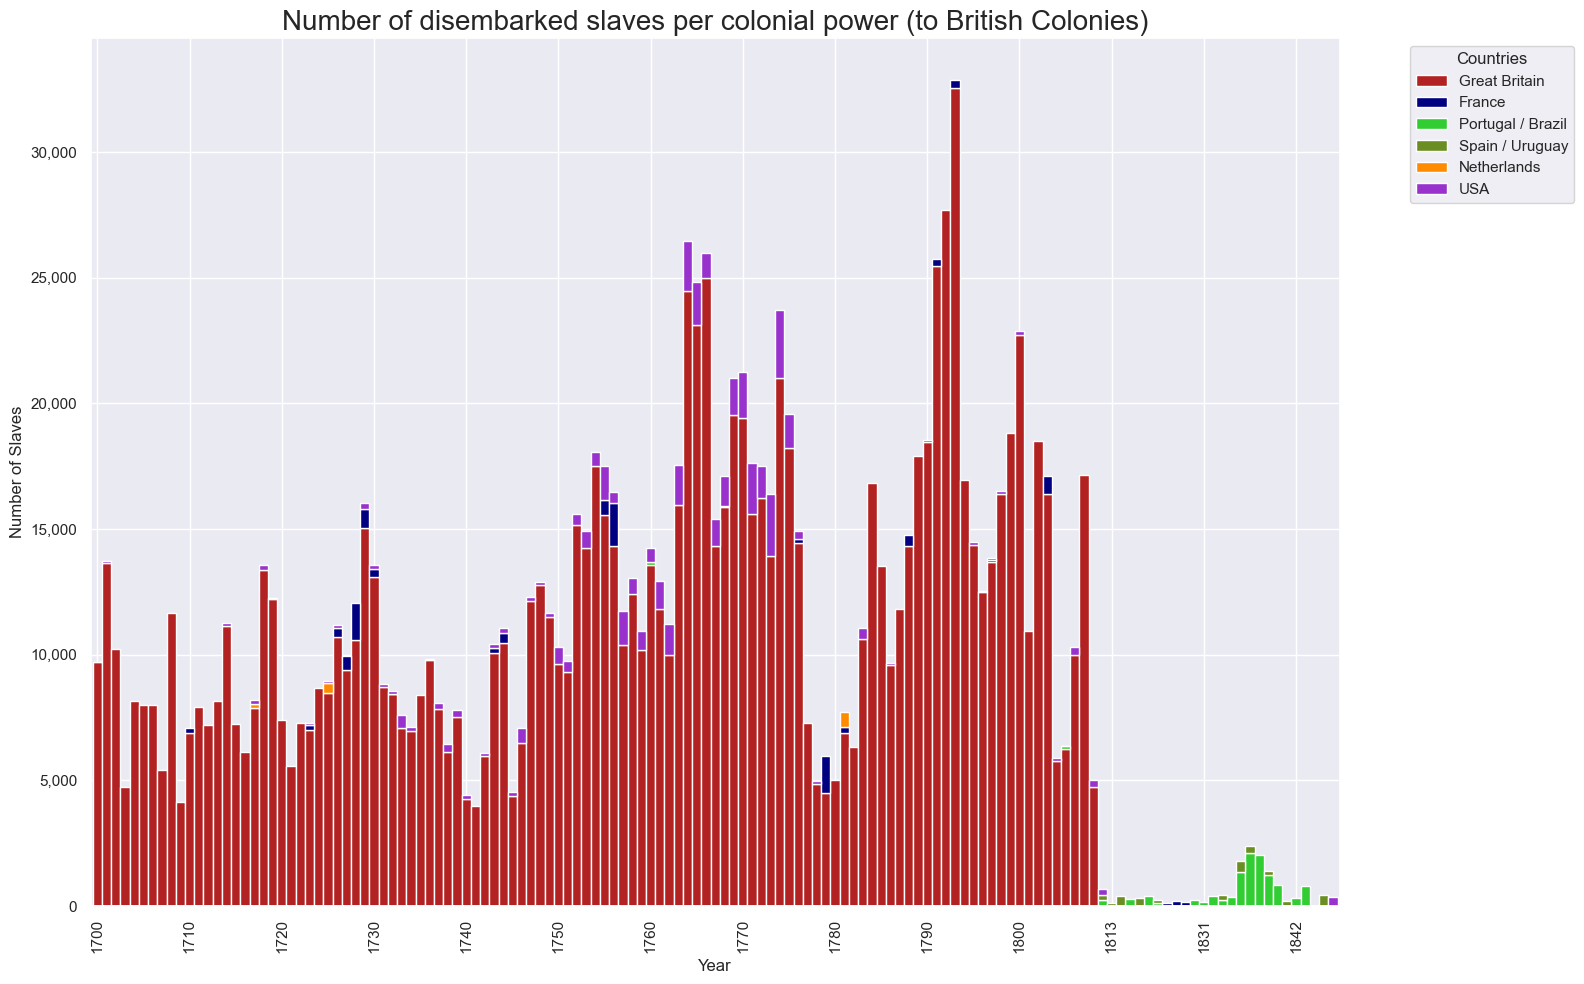

In [22]:
#total number of slaves per year including GB

#group by country and year
sv_grouped = sv_grouped_filtered_START.groupby(['NATINIMP', 'YEARAM'], as_index=False)['SLAMIMP'].sum()

#define all countries for ratio calculation (including GB)
all_countries = [
    "Great Britain",
    "France",
    "Portugal / Brazil",
    "Spain / Uruguay",
    "Netherlands",
    "USA"
]

country_order = [
    "Great Britain",
    "France",
    "Portugal / Brazil",
    "Spain / Uruguay",
    "Netherlands",
    "USA"
]
color_order = [
    color_mapping["Great Britain"],
    color_mapping["France"],
    color_mapping["Portugal / Brazil"],
    color_mapping["Spain / Uruguay"],
    color_mapping["Netherlands"],
    color_mapping["USA"]
]

#filter only countries to show
sv_grouped_filtered = sv_grouped[sv_grouped['NATINIMP'].isin(country_order)].copy()
sv_grouped_filtered['NATINIMP'] = pd.Categorical(sv_grouped_filtered['NATINIMP'], categories=country_order, ordered=True)

#pivot for barplot (years as index, countries as columns, correct order)
pivot_df = sv_grouped_filtered.pivot(index='YEARAM', columns='NATINIMP', values='SLAMIMP').fillna(0)
pivot_df = pivot_df[country_order]  # enforce column order

#plotting
plt.figure(figsize=(16, 10))
pivot_df.plot(kind='bar', stacked=True, color=color_order, width=1.0, ax=plt.gca())

plt.title("Number of disembarked slaves per colonial power (to British Colonies)", size=20)
plt.xlabel("Year")
plt.ylabel("Number of Slaves")
plt.legend(title='Countries', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: format(int(x), ',')))
plt.xticks(ticks=range(0, len(pivot_df.index), 10), labels=pivot_df.index[::10], rotation=90)
plt.tight_layout()
plt.show()

In [23]:
#share of total embarked slaves per country for the whole period
#sum
total_by_power = sv_grouped_filtered_START.groupby('NATINIMP')['SLAMIMP'].sum().reset_index()

#overall total
overall_total = total_by_power['SLAMIMP'].sum()

#share for each power
total_by_power['SHARE'] = total_by_power['SLAMIMP'] / overall_total

total_by_power

,NATINIMP,SLAMIMP,SHARE
0,France,10922.0,0.008067
1,Great Britain,1287970.0,0.951254
2,Netherlands,1115.0,0.000824
3,Portugal / Brazil,11319.0,0.008360
4,Spain / Uruguay,2901.0,0.002143
5,USA,39743.0,0.029353


##### Places where ships where constructed and registered

In [24]:
constructed_gdf_all_landing_ports = gpd.read_file(data_dir+"PLACE_CONSTRUCTED_UK.gpkg")
registered_gdf_all_landing_ports = gpd.read_file(data_dir+"PLACE_REGISTERED_UK.gpkg")

In [37]:
#output paths
constructed_out = data_dir+"PLACE_CONSTRUCTED_UK_dropDUPL.gpkg"
registered_out = data_dir+"PLACE_REGISTERED_UK_dropDUPL.gpkg"

# Remove duplicates in PLACE_CONSTRUCTED_UK.gpkg
constructed_gdf_all_landing_ports = constructed_gdf_all_landing_ports.sort_values("VOYAGEID")
constructed_gdf_all_landing_ports = constructed_gdf_all_landing_ports.drop_duplicates(subset=["SHIPNAME", "YRCONS"], keep="first")
constructed_gdf_all_landing_ports.to_file(constructed_out, driver="GPKG")

# Remove duplicates in PLACE_REGISTERED_UK.gpkg
registered_gdf_all_landing_ports = registered_gdf_all_landing_ports.sort_values("VOYAGEID")
registered_gdf_all_landing_ports = registered_gdf_all_landing_ports.drop_duplicates(subset=["SHIPNAME", "YRREG"], keep="first")
registered_gdf_all_landing_ports.to_file(registered_out, driver="GPKG")

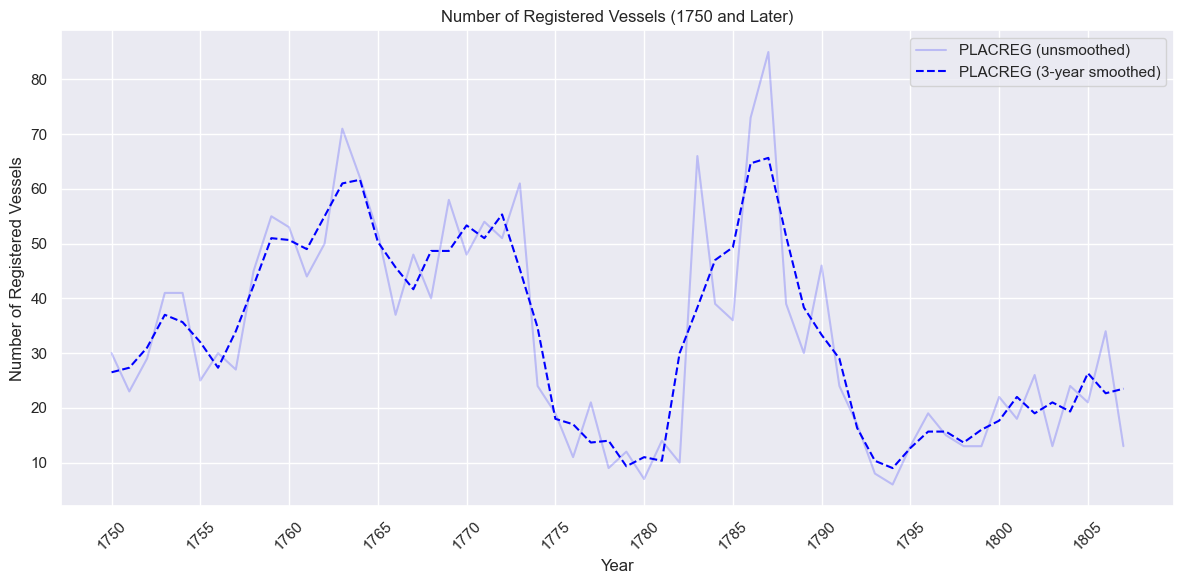

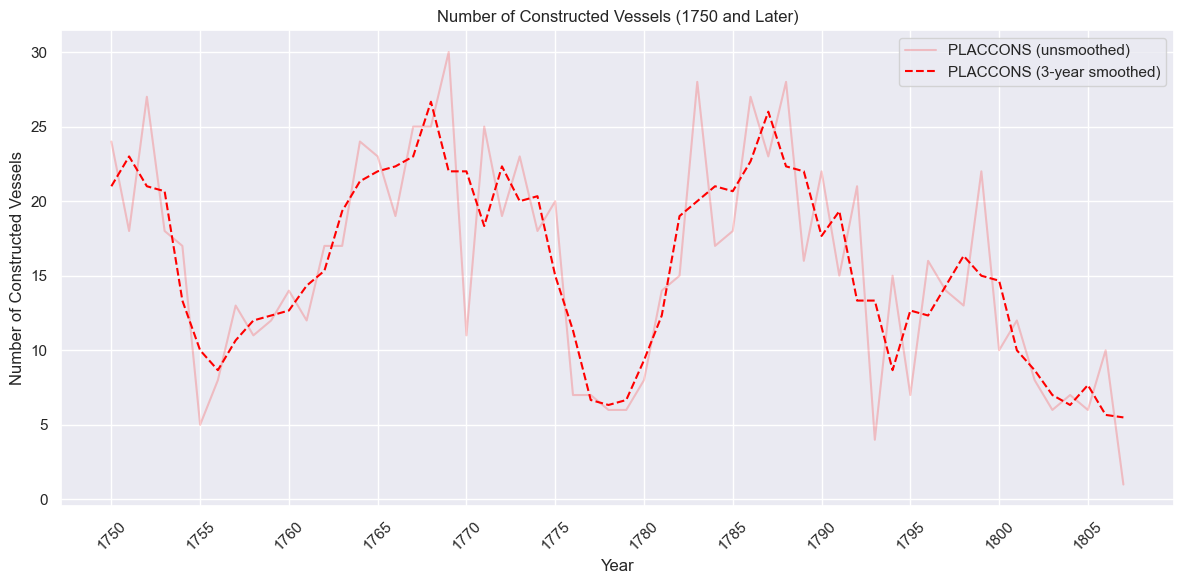

In [38]:
#load files
places_registered_UK = gpd.read_file(data_dir+"PLACE_REGISTERED_UK_dropDUPL.gpkg")
places_constructed_UK = gpd.read_file(data_dir+"PLACE_CONSTRUCTED_UK_dropDUPL.gpkg")

#filter for years 1750 and later
filtered_vessels_REG = places_registered_UK[places_registered_UK["YRREG"] >= 1750]
filtered_vessels_CONS = places_constructed_UK[places_constructed_UK["YRCONS"] >= 1750]

#grouping for unsmoothed data
unsmoothed_reg = filtered_vessels_REG.groupby("YRREG")["PLACREG"].count()
unsmoothed_cons = filtered_vessels_CONS.groupby("YRCONS")["PLACCONS"].count()

#3-year moving average smoothing (average of previous, current, and next year)
smoothed_reg = unsmoothed_reg.rolling(window=3, center=True, min_periods=1).mean()
smoothed_cons = unsmoothed_cons.rolling(window=3, center=True, min_periods=1).mean()

#plotting registered vessels (PLACREG)
plt.figure(figsize=(12, 6))
plt.plot(unsmoothed_reg.index, unsmoothed_reg, label="PLACREG (unsmoothed)", color="blue", alpha=0.2)
plt.plot(smoothed_reg.index, smoothed_reg, label="PLACREG (3-year smoothed)", color="blue", linestyle="--")
plt.title("Number of Registered Vessels (1750 and Later)")
plt.xlabel("Year")
plt.ylabel("Number of Registered Vessels")
plt.legend()
plt.gca().get_yaxis().set_major_formatter(mticker.FuncFormatter(lambda x, _: format(int(x), ',')))
plt.xticks(
    range(int(filtered_vessels_REG["YRREG"].min()), int(filtered_vessels_REG["YRREG"].max()) + 1, 5),
    rotation=45
)
plt.tight_layout()
plt.show()

#plotting constructed vessels (PLACCONS)
plt.figure(figsize=(12, 6))
plt.plot(unsmoothed_cons.index, unsmoothed_cons, label="PLACCONS (unsmoothed)", color="red", alpha=0.2)
plt.plot(smoothed_cons.index, smoothed_cons, label="PLACCONS (3-year smoothed)", color="red", linestyle="--")
plt.title("Number of Constructed Vessels (1750 and Later)")
plt.xlabel("Year")
plt.ylabel("Number of Constructed Vessels")
plt.legend()
plt.gca().get_yaxis().set_major_formatter(mticker.FuncFormatter(lambda x, _: format(int(x), ',')))
plt.xticks(
    range(int(filtered_vessels_CONS["YRCONS"].min()), int(filtered_vessels_CONS["YRCONS"].max()) + 1, 5),
    rotation=45
)
plt.tight_layout()
plt.show()

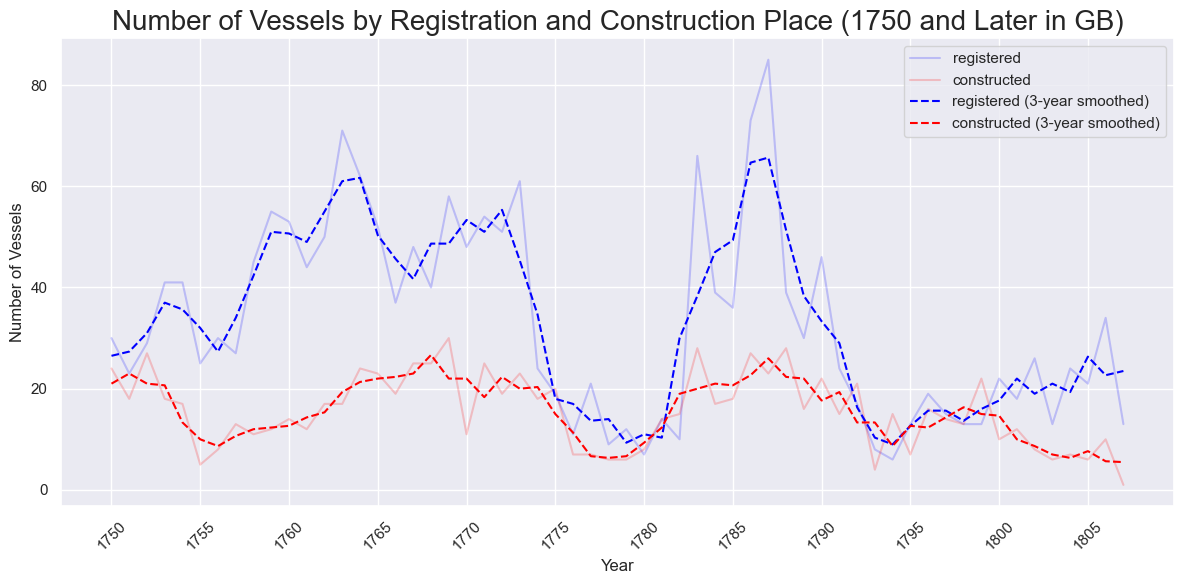

In [40]:
#plotting in one plot both registered and constructed vessels

plt.figure(figsize=(12, 6))

#plot unsmoothed data
plt.plot(unsmoothed_reg.index, unsmoothed_reg, label="registered", color="blue", alpha=0.2)
plt.plot(unsmoothed_cons.index, unsmoothed_cons, label="constructed", color="red", alpha=0.2)

#plot smoothed data
plt.plot(smoothed_reg.index, smoothed_reg, label="registered (3-year smoothed)", color="blue", linestyle="--")
plt.plot(smoothed_cons.index, smoothed_cons, label="constructed (3-year smoothed)", color="red", linestyle="--")

plt.title("Number of Vessels by Registration and Construction Place (1750 and Later in GB)", size=20)
plt.xlabel("Year")
plt.ylabel("Number of Vessels")
plt.legend()

plt.gca().get_yaxis().set_major_formatter(mticker.FuncFormatter(lambda x, _: format(int(x), ',')))

plt.xticks(range(int(filtered_vessels_REG["YRREG"].min()), int(filtered_vessels_REG["YRREG"].max()) + 1, 5), rotation=45)

# Show plot
plt.tight_layout()
plt.show()

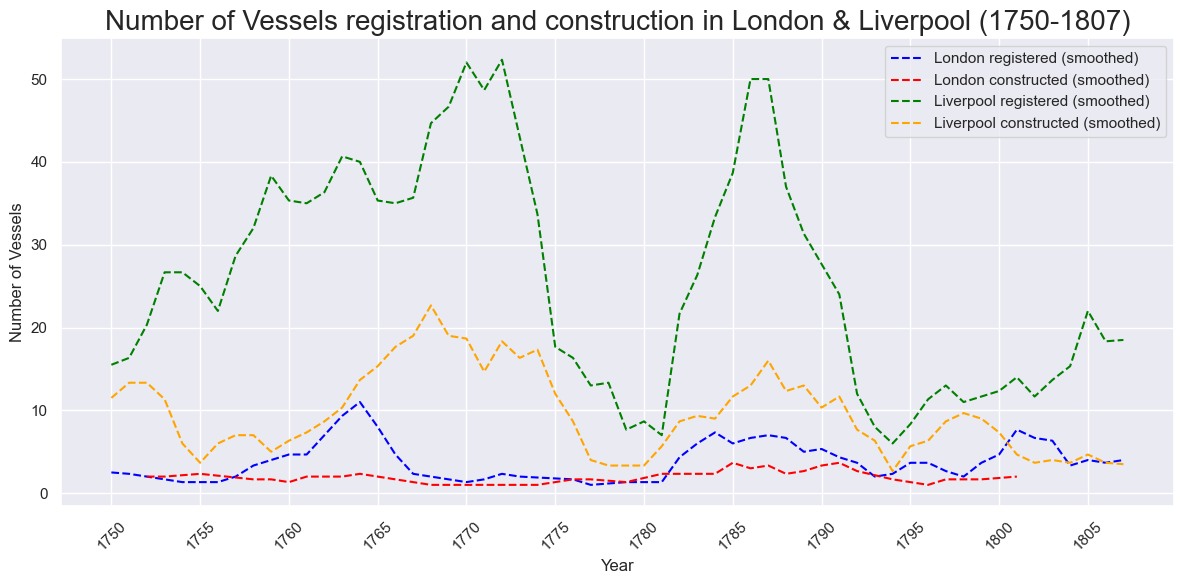

In [45]:
#plotting in one plot both registered and constructed vessels, split for London and Liverpool

plt.figure(figsize=(12, 6))

#filter for London and Liverpool
london_reg = filtered_vessels_REG[filtered_vessels_REG["PLACREG"].str.lower().str.contains("london", na=False)]
liverpool_reg = filtered_vessels_REG[filtered_vessels_REG["PLACREG"].str.lower().str.contains("liverpool", na=False)]
london_cons = filtered_vessels_CONS[filtered_vessels_CONS["PLACCONS"].str.lower().str.contains("london", na=False)]
liverpool_cons = filtered_vessels_CONS[filtered_vessels_CONS["PLACCONS"].str.lower().str.contains("liverpool", na=False)]

#group and smooth
london_reg_count = london_reg.groupby("YRREG")["PLACREG"].count()
liverpool_reg_count = liverpool_reg.groupby("YRREG")["PLACREG"].count()
london_cons_count = london_cons.groupby("YRCONS")["PLACCONS"].count()
liverpool_cons_count = liverpool_cons.groupby("YRCONS")["PLACCONS"].count()

london_reg_smooth = london_reg_count.rolling(window=3, center=True, min_periods=1).mean()
liverpool_reg_smooth = liverpool_reg_count.rolling(window=3, center=True, min_periods=1).mean()
london_cons_smooth = london_cons_count.rolling(window=3, center=True, min_periods=1).mean()
liverpool_cons_smooth = liverpool_cons_count.rolling(window=3, center=True, min_periods=1).mean()

plt.plot(london_reg_smooth.index, london_reg_smooth, label="London registered (smoothed)", color="blue", linestyle="--")
plt.plot(london_cons_smooth.index, london_cons_smooth, label="London constructed (smoothed)", color="red", linestyle="--")

plt.plot(liverpool_reg_smooth.index, liverpool_reg_smooth, label="Liverpool registered (smoothed)", color="green", linestyle="--")
plt.plot(liverpool_cons_smooth.index, liverpool_cons_smooth, label="Liverpool constructed (smoothed)", color="orange", linestyle="--")

plt.title("Number of Vessels registration and construction in London & Liverpool (1750-1807)", size=20)
plt.xlabel("Year")
plt.ylabel("Number of Vessels")
plt.legend()
plt.gca().get_yaxis().set_major_formatter(mticker.FuncFormatter(lambda x, _: format(int(x), ',')))

years = sorted(set(london_reg_count.index).union(liverpool_reg_count.index).union(london_cons_count.index).union(liverpool_cons_count.index))
if years:
    plt.xticks(range(int(min(years)), int(max(years)) + 1, 5), rotation=45)

plt.tight_layout()
plt.show()

In [74]:
places_registered_UK['NATINIMP'].value_counts()

NATINIMP
Great Britain       2992
USA                    8
Denmark / Baltic       1
Name: count, dtype: int64

In [75]:
places_constructed_UK['NATINIMP'].value_counts()

NATINIMP
Great Britain        1803
France                 18
USA                     6
Portugal / Brazil       5
nan                     5
Spain / Uruguay         3
Other                   1
Name: count, dtype: int64

### Q3 TITLE

For MA question 3: Daten mit Startpunkt (MJBYPTIMP), Endpunkt (MJSLPTIMP), Menge (SLAMIMP), NATINIMP, YEARAM

In [25]:
#import whole csv as dataframe
stdb = pd.read_csv(data_dir+'stdb.csv')

C:\Users\andre\AppData\Local\Temp\ipykernel_15556\325477104.py:2: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  stdb = pd.read_csv(data_dir+'stdb.csv')


In [26]:
#filter of stdb for relevant columns
stdb3 = stdb[["YEARAM","NATINIMP","SLAMIMP","MJBYPTIMP","MJSLPTIMP"]]

In [27]:
stdb3.head(5)

,YEARAM,NATINIMP,SLAMIMP,MJBYPTIMP,MJSLPTIMP
0,1817,Portugal / Brazil,290.0,Mozambique,"Bahia, port unspecified"
1,1817,Portugal / Brazil,223.0,Mozambique,"Bahia, port unspecified"
2,1817,Portugal / Brazil,350.0,Cabinda,"Bahia, port unspecified"
3,1817,Portugal / Brazil,342.0,Quilimane,"Bahia, port unspecified"
4,1817,Portugal / Brazil,516.0,Cabinda,"Bahia, port unspecified"


In [28]:
#drop rows with NaN in relevant columns
stdb3 = stdb3.dropna(subset=["YEARAM","NATINIMP","MJBYPTIMP","MJSLPTIMP"])
stdb3 = stdb3[stdb3["YEARAM"]!= 'nan']
stdb3 = stdb3[stdb3["NATINIMP"]!= 'nan']
stdb3 = stdb3[stdb3["MJBYPTIMP"]!= 'nan']
stdb3 = stdb3[stdb3["MJSLPTIMP"]!= 'nan']

In [29]:
#rename columns
stdb3.rename(columns={"YEARAM": "year", "NATINIMP": "country", "SLAMIMP": "number", "MJBYPTIMP": "port_buy", "MJSLPTIMP": "port_sel"}, inplace=True)

In [30]:
#import gazetteer for the toponym resolution
ports = pd.read_csv(data_dir+"slave-voyages-ports.csv")

In [31]:
#toponym resolution for columns ['port_buy','port_sel']
start_time = time.time()
for column in ['port_buy','port_sel']:
    column_name = column
    #longitude
    stdb3[column_name+'_lng'] = stdb3.apply(lambda x: ports.loc[ports['port'] == x[column], 'long'].reset_index(drop=True).values[0] if x[column] in ports['port'].values else None, axis=1)
    #latitude
    stdb3[column_name+'_lat'] = stdb3.apply(lambda x: ports.loc[ports['port'] == x[column], 'lat'].reset_index(drop=True).values[0] if x[column] in ports['port'].values else None, axis=1)
    print(column+ " finished: "+str(round(time.time() - start_time,2))+"s")

port_buy finished: 19.39s
port_sel finished: 41.17s


In [32]:
#for every year, assign colonial power to buy and sel ports, via spatial join

#path to yearly shapefiles for colonies
colonies_folder = colonies_dir+"yearly_shapefiles"

#prepare result columns
stdb3['colonial_power_buy'] = None
stdb3['colonial_power_sel'] = None

for year in sorted(stdb3['year'].unique()):
    shp_path = os.path.join(colonies_folder, f"colonies_{year}.gpkg")
    if not os.path.exists(shp_path):
        continue
    colonies_gdf = gpd.read_file(shp_path)[['geometry', 'colonizer_grouped']]
    
    colonies_gdf = colonies_gdf[colonies_gdf.geometry.notnull()]
    if colonies_gdf.empty:
        continue
    colonies_gdf = colonies_gdf.to_crs(epsg=4326)

    #buy ports
    year_mask_buy = stdb3['year'] == year
    gdf_buy = gpd.GeoDataFrame(
        stdb3.loc[year_mask_buy, :],
        geometry=gpd.points_from_xy(stdb3.loc[year_mask_buy, 'port_buy_lng'], stdb3.loc[year_mask_buy, 'port_buy_lat']),
        crs="EPSG:4326"
    )
    joined_buy = gpd.sjoin(gdf_buy, colonies_gdf, how='left', predicate='within')
    stdb3.loc[year_mask_buy, 'colonial_power_buy'] = joined_buy['colonizer_grouped'].values

    #sel ports
    year_mask_sel = stdb3['year'] == year
    gdf_sel = gpd.GeoDataFrame(
        stdb3.loc[year_mask_sel, :],
        geometry=gpd.points_from_xy(stdb3.loc[year_mask_sel, 'port_sel_lng'], stdb3.loc[year_mask_sel, 'port_sel_lat']),
        crs="EPSG:4326"
    )
    joined_sel = gpd.sjoin(gdf_sel, colonies_gdf, how='left', predicate='within')
    stdb3.loc[year_mask_sel, 'colonial_power_sel'] = joined_sel['colonizer_grouped'].values

In [33]:
#where were slaves bought?
stdb3.colonial_power_buy.value_counts()

colonial_power_buy
zzz. Not colonized           12200
Portugal                      5830
United Kingdom                 114
zzzz. No longer colonized       17
Name: count, dtype: int64

In [34]:
#where were slaves sold
stdb3.colonial_power_sel.value_counts()

colonial_power_sel
United Kingdom               7962
Portugal                     3474
Spain                        2747
zzzz. No longer colonized    2003
Netherlands                  1134
France                       1085
z. Multiple colonizers        127
zzz. Not colonized             25
zz. Colonizer                   8
Name: count, dtype: int64

In [35]:
#mapping colonial powers to slave trading countries

country_to_power = {
    "United Kingdom": "Great Britain",
    "Portugal": "Portugal / Brazil",
    "Spain": "Spain / Uruguay",
    "Netherlands": "Netherlands",
    "France": "France",
    "USA": "USA",
}

def map_colonial_power(val):
    return country_to_power[val] if val in country_to_power else val

stdb3['colonial_power_buy'] = stdb3['colonial_power_buy'].apply(map_colonial_power)
stdb3['colonial_power_sel'] = stdb3['colonial_power_sel'].apply(map_colonial_power)

In [36]:
#drop rows with NaN in colonial power columns
stdb3.dropna(subset=["colonial_power_buy","colonial_power_sel"], inplace=True)

In [37]:
stdb3.head()

,year,country,number,port_buy,port_sel,port_buy_lng,port_buy_lat,port_sel_lng,port_sel_lat,colonial_power_buy,colonial_power_sel
16,1817,Portugal / Brazil,545.0,Cabinda,Rio de Janeiro,12.2,-5.55,-43.23333,-22.9,Portugal / Brazil,Portugal / Brazil
17,1817,Portugal / Brazil,459.0,Cabinda,Rio de Janeiro,12.2,-5.55,-43.23333,-22.9,Portugal / Brazil,Portugal / Brazil
18,1817,Portugal / Brazil,457.0,Cabinda,Rio de Janeiro,12.2,-5.55,-43.23333,-22.9,Portugal / Brazil,Portugal / Brazil
19,1817,Portugal / Brazil,598.0,Benguela,Rio de Janeiro,13.40722,-12.57833,-43.23333,-22.9,Portugal / Brazil,Portugal / Brazil
20,1817,Portugal / Brazil,521.0,Quilimane,Rio de Janeiro,36.88833,-17.87861,-43.23333,-22.9,zzz. Not colonized,Portugal / Brazil


In [38]:
#dataFrames where colonial_power_buy == colonial_power_sel and where they are not
stdb3_same = stdb3[stdb3['colonial_power_buy'] == stdb3['colonial_power_sel']]
stdb3_diff = stdb3[stdb3['colonial_power_buy'] != stdb3['colonial_power_sel']]
stdb3_same_NATINIMP = stdb3[stdb3['colonial_power_sel'] == stdb3['country']]

In [39]:
#buyer colonial power matches seller colonial power
stdb3_same.info()

<class 'pandas.core.frame.DataFrame'>
Index: 793 entries, 16 to 35983
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   year                793 non-null    int64  
 1   country             793 non-null    object 
 2   number              791 non-null    float64
 3   port_buy            793 non-null    object 
 4   port_sel            793 non-null    object 
 5   port_buy_lng        793 non-null    object 
 6   port_buy_lat        793 non-null    object 
 7   port_sel_lng        793 non-null    object 
 8   port_sel_lat        793 non-null    object 
 9   colonial_power_buy  793 non-null    object 
 10  colonial_power_sel  793 non-null    object 
dtypes: float64(1), int64(1), object(9)
memory usage: 74.3+ KB


In [40]:
#buyer colonial power does not match seller colonial power
stdb3_diff.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10880 entries, 20 to 36106
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   year                10880 non-null  int64  
 1   country             10880 non-null  object 
 2   number              10871 non-null  float64
 3   port_buy            10880 non-null  object 
 4   port_sel            10880 non-null  object 
 5   port_buy_lng        10880 non-null  object 
 6   port_buy_lat        10880 non-null  object 
 7   port_sel_lng        10880 non-null  object 
 8   port_sel_lat        10880 non-null  object 
 9   colonial_power_buy  10880 non-null  object 
 10  colonial_power_sel  10880 non-null  object 
dtypes: float64(1), int64(1), object(9)
memory usage: 1020.0+ KB


In [41]:
#trading country matches selling colonial power
stdb3_same_NATINIMP.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8757 entries, 16 to 35988
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   year                8757 non-null   int64  
 1   country             8757 non-null   object 
 2   number              8752 non-null   float64
 3   port_buy            8757 non-null   object 
 4   port_sel            8757 non-null   object 
 5   port_buy_lng        8757 non-null   object 
 6   port_buy_lat        8757 non-null   object 
 7   port_sel_lng        8757 non-null   object 
 8   port_sel_lat        8757 non-null   object 
 9   colonial_power_buy  8757 non-null   object 
 10  colonial_power_sel  8757 non-null   object 
dtypes: float64(1), int64(1), object(9)
memory usage: 821.0+ KB


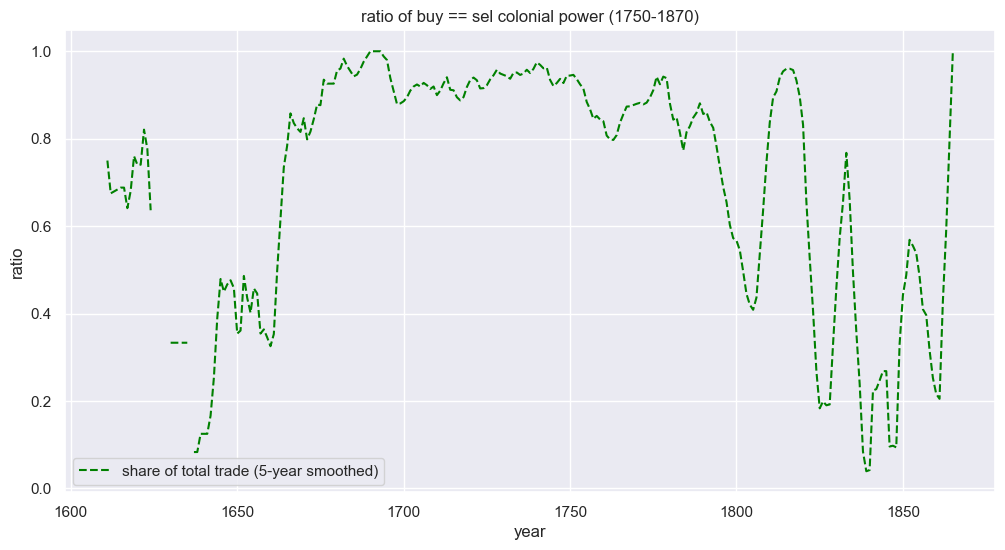

In [42]:
#plotting number of voyages per year where buy colonial power == sel colonial power

#count all voyages per year (total trade)
total_per_year = stdb3.groupby("year")["country"].count()

# Count: voyages where buy == sel == country (your filtered subset)
same_nat_per_year = stdb3_same_NATINIMP.groupby("year")["country"].count()

# Calculate ratio (share)
share_per_year = same_nat_per_year / total_per_year

# 5-year moving average smoothing (centered)
share_per_year_smooth = share_per_year.rolling(window=5, center=True, min_periods=1).mean()

# Filter for years 1750-1870
years_mask = (share_per_year.index >= 1600) & (share_per_year.index <= 1870)
share_per_year_filtered = share_per_year.loc[years_mask]
share_per_year_smooth_filtered = share_per_year_smooth.loc[years_mask]

plt.figure(figsize=(12, 6))
#plt.plot(share_per_year_filtered.index, share_per_year_filtered, label="share of total trade (raw)", color="green", alpha=0.3)
plt.plot(share_per_year_smooth_filtered.index, share_per_year_smooth_filtered, label="share of total trade (5-year smoothed)", color="green", linestyle="--")
plt.ylabel("ratio")
plt.xlabel("year")
plt.title("ratio of buy == sel colonial power (1750-1870)")
plt.legend()
plt.show()

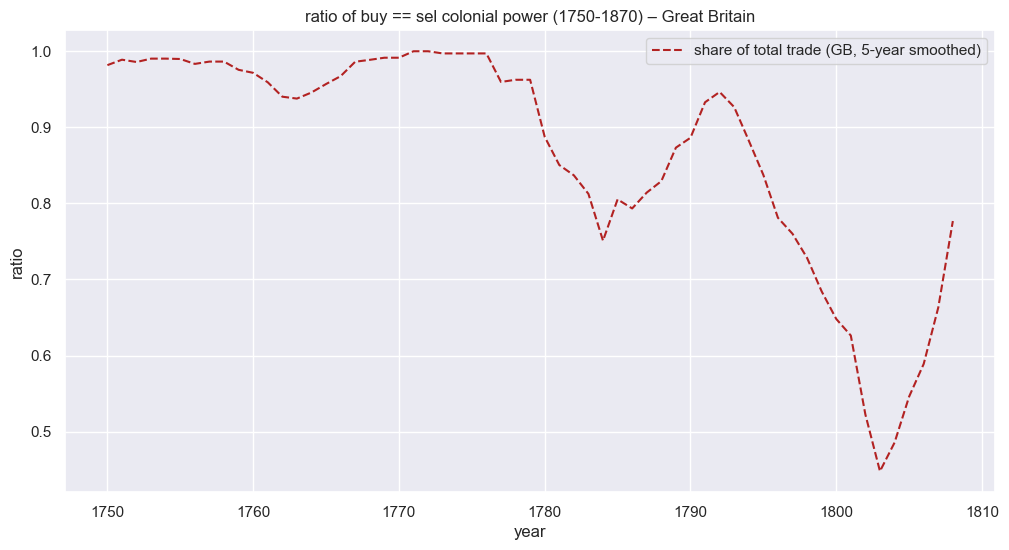

In [43]:
#plotting share of total trade per year, only for 1750-1870 and only for Great Britain

#filter for Great Britain
stdb3_gb = stdb3[stdb3['country'] == 'Great Britain']
stdb3_same_NATINIMP_gb = stdb3_same_NATINIMP[stdb3_same_NATINIMP['country'] == 'Great Britain']

#count all voyages per year (total trade, GB only)
total_per_year_gb = stdb3_gb.groupby("year")["country"].count()

#count voyages where buy == sel == country (GB only)
same_nat_per_year_gb = stdb3_same_NATINIMP_gb.groupby("year")["country"].count()

# Calculate ratio (share)
share_per_year_gb = same_nat_per_year_gb / total_per_year_gb

# 5-year moving average smoothing (centered)
share_per_year_gb_smooth = share_per_year_gb.rolling(window=5, center=True, min_periods=1).mean()

# Filter for years 1750-1870
years_mask_gb = (share_per_year_gb.index >= 1750) & (share_per_year_gb.index <= 1870)
share_per_year_filtered_gb = share_per_year_gb.loc[years_mask_gb]
share_per_year_gb_smooth_filtered = share_per_year_gb_smooth.loc[years_mask_gb]

plt.figure(figsize=(12, 6))
#plt.plot(share_per_year_filtered_gb.index, share_per_year_filtered_gb, label="share of total trade (GB, raw)", color="firebrick", alpha=0.3)
plt.plot(share_per_year_gb_smooth_filtered.index, share_per_year_gb_smooth_filtered, label="share of total trade (GB, 5-year smoothed)", color="firebrick", linestyle="--")
plt.ylabel("ratio")
plt.xlabel("year")
plt.title("ratio of buy == sel colonial power (1750-1870) – Great Britain")
plt.legend()
plt.show()

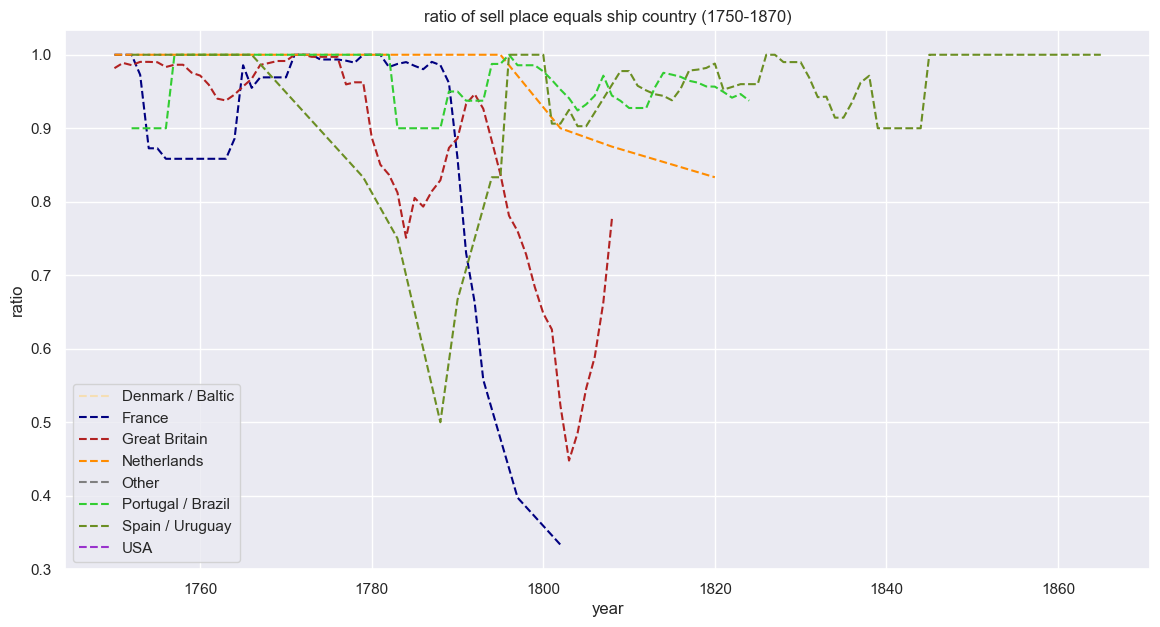

In [44]:
# plotting share of total trade per year, 1750-1870, for all countrie

countries = stdb3['country'].unique()
plt.figure(figsize=(14, 7))

for country in sorted(countries):
    stdb3_c = stdb3[stdb3['country'] == country]
    stdb3_same_NATINIMP_c = stdb3_same_NATINIMP[stdb3_same_NATINIMP['country'] == country]
    total_per_year_c = stdb3_c.groupby("year")["country"].count()
    same_nat_per_year_c = stdb3_same_NATINIMP_c.groupby("year")["country"].count()
    share_per_year_c = same_nat_per_year_c / total_per_year_c

    #5-year moving average smoothing (centered)
    share_per_year_c_smooth = share_per_year_c.rolling(window=5, center=True, min_periods=1).mean()

    years_mask_c = (share_per_year_c.index >= 1750) & (share_per_year_c.index <= 1870)
    share_per_year_filtered_c = share_per_year_c.loc[years_mask_c]
    share_per_year_c_smooth_filtered = share_per_year_c_smooth.loc[years_mask_c]
    if not share_per_year_c_smooth_filtered.empty:
        color = color_mapping.get(country, color_mapping["Other"])
        plt.plot(
            share_per_year_c_smooth_filtered.index,
            share_per_year_c_smooth_filtered,
            label=country,
            color=color,
            linestyle="--"
        )
        # Optionally, also plot the raw line with alpha for context:
        # plt.plot(share_per_year_filtered_c.index, share_per_year_filtered_c, color=color, alpha=0.2)

plt.ylabel("ratio")
plt.xlabel("year")
plt.title("ratio of sell place equals ship country (1750-1870)")
plt.legend()
plt.show()

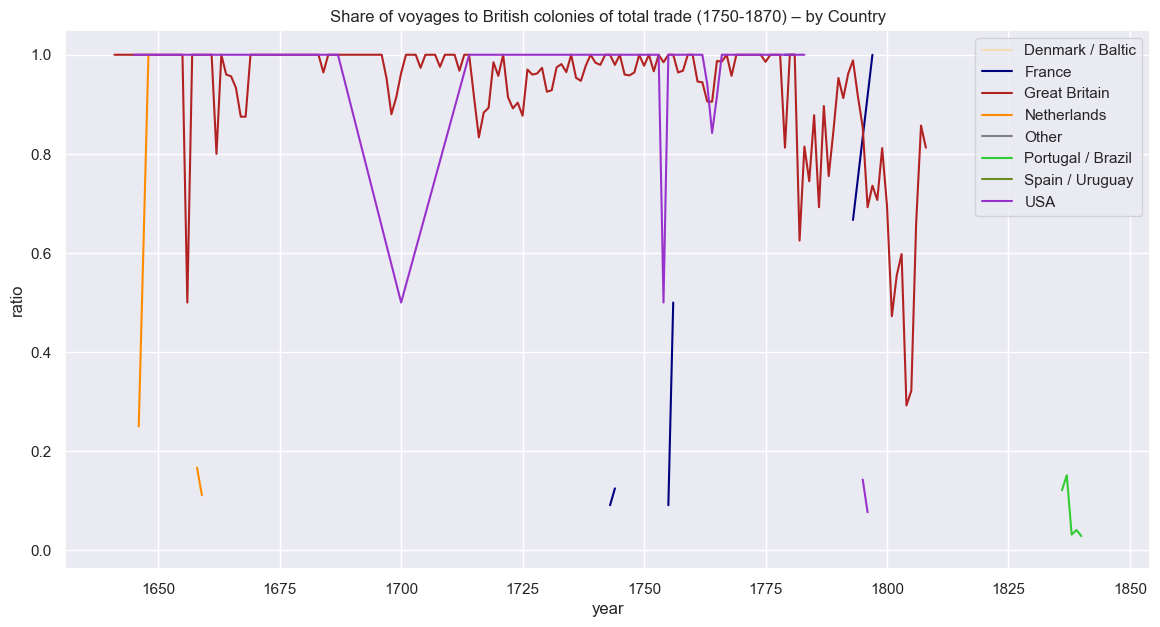

In [45]:
# share of voyages to GB colonies per year, for each country, 1750-1870


#filter for GB colonies as destination (colonial_power_sel == 'Great Britain')
stdb3_gbcol = stdb3[stdb3['colonial_power_sel'] == 'Great Britain']

countries = stdb3['country'].unique()
plt.figure(figsize=(14, 7))

for country in sorted(countries):
    #all voyages by country
    stdb3_c = stdb3[stdb3['country'] == country]
    #voyages by country to GB colonies
    stdb3_gbcol_c = stdb3_gbcol[stdb3_gbcol['country'] == country]
    #count per year
    total_per_year_c = stdb3_c.groupby("year")["country"].count()
    to_gbcol_per_year_c = stdb3_gbcol_c.groupby("year")["country"].count()
    #ratio
    ratio_per_year_c = to_gbcol_per_year_c / total_per_year_c
    #filter years
    years_mask_c = (ratio_per_year_c.index >= 1600) & (ratio_per_year_c.index <= 1870)
    ratio_per_year_filtered_c = ratio_per_year_c.loc[years_mask_c]
    if not ratio_per_year_filtered_c.empty:
        color = color_mapping.get(country, color_mapping["Other"])
        plt.plot(ratio_per_year_filtered_c.index, ratio_per_year_filtered_c, label=country, color=color)

plt.ylabel("ratio")
plt.xlabel("year")
plt.title("Share of voyages to British colonies of total trade (1750-1870) – by Country")
plt.legend()
plt.show()

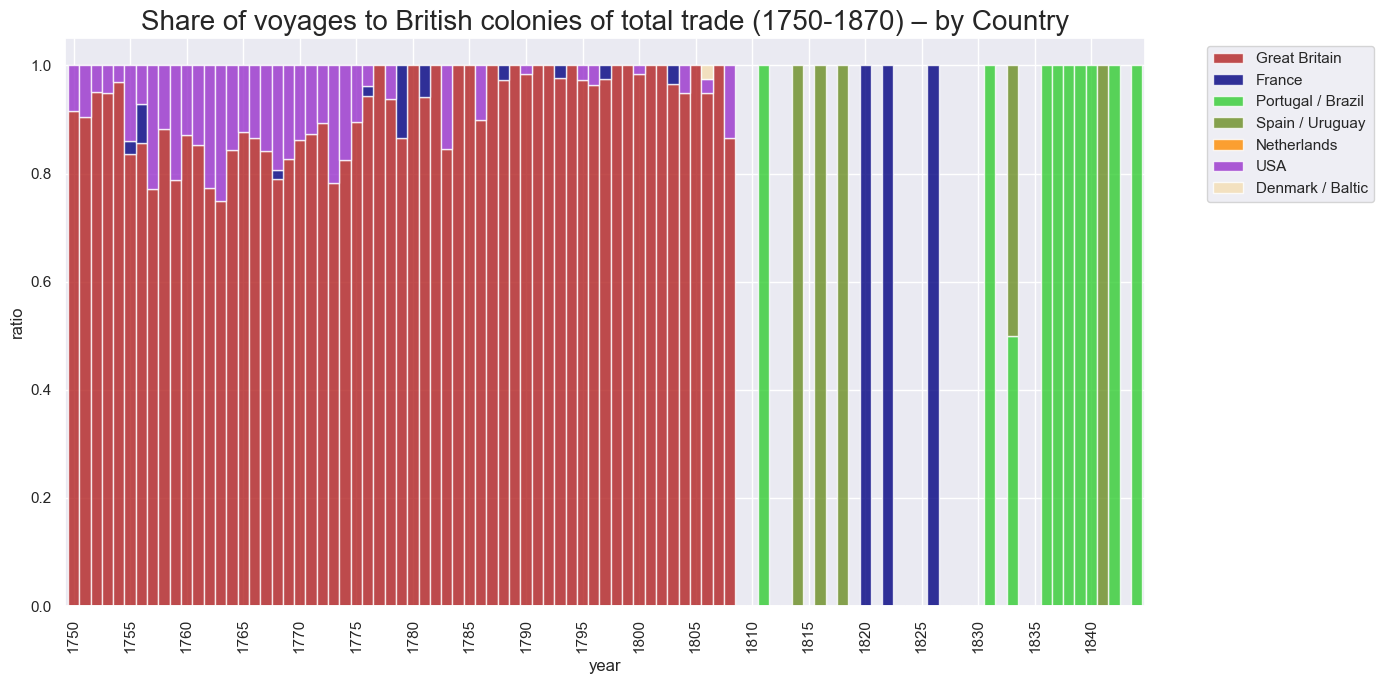

In [46]:
#share of voyages to GB colonies per year, for each country, 1750-1870, as stacked bar

#order
country_order = [
    "Great Britain",
    "France",
    "Portugal / Brazil",
    "Spain / Uruguay",
    "Netherlands",
    "USA"
]

#total GB voyages per year (denominator)
total_per_year = stdb3[stdb3['colonial_power_sel'] == "Great Britain"].groupby("year").size()

#voyages to GB colonies by each country
stdb3_gbcol = stdb3[stdb3['colonial_power_sel'] == 'Great Britain']
to_gbcol_per_year = stdb3_gbcol.groupby(["year", "country"]).size().unstack(fill_value=0)

#ratios: share of GB voyages going to GB colonies per country
ratio_per_year = to_gbcol_per_year.div(total_per_year, axis=0)

#ensure full year range (1750–1870), fill missing with 0
years = range(1750, 1845)
ratio_per_year = ratio_per_year.reindex(years, fill_value=0)

#reorder columns
all_countries = list(ratio_per_year.columns)
extra_countries = [c for c in all_countries if c not in country_order]
ordered_cols = country_order + extra_countries
ratio_per_year = ratio_per_year.reindex(columns=ordered_cols, fill_value=0)

#plot stacked bar
plt.figure(figsize=(14, 7))
ratio_per_year.plot(
    kind="bar",
    stacked=True,
    color=[color_mapping.get(c, color_mapping["Other"]) for c in ratio_per_year.columns],
    alpha=0.8,
    width=1.0,
    ax=plt.gca()
)

plt.ylabel("ratio")
plt.xlabel("year")
plt.xticks(ticks=range(0, len(ratio_per_year.index), 5), labels=ratio_per_year.index[::5], rotation=90)
plt.title("Share of voyages to British colonies of total trade (1750-1870) – by Country", size=20)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


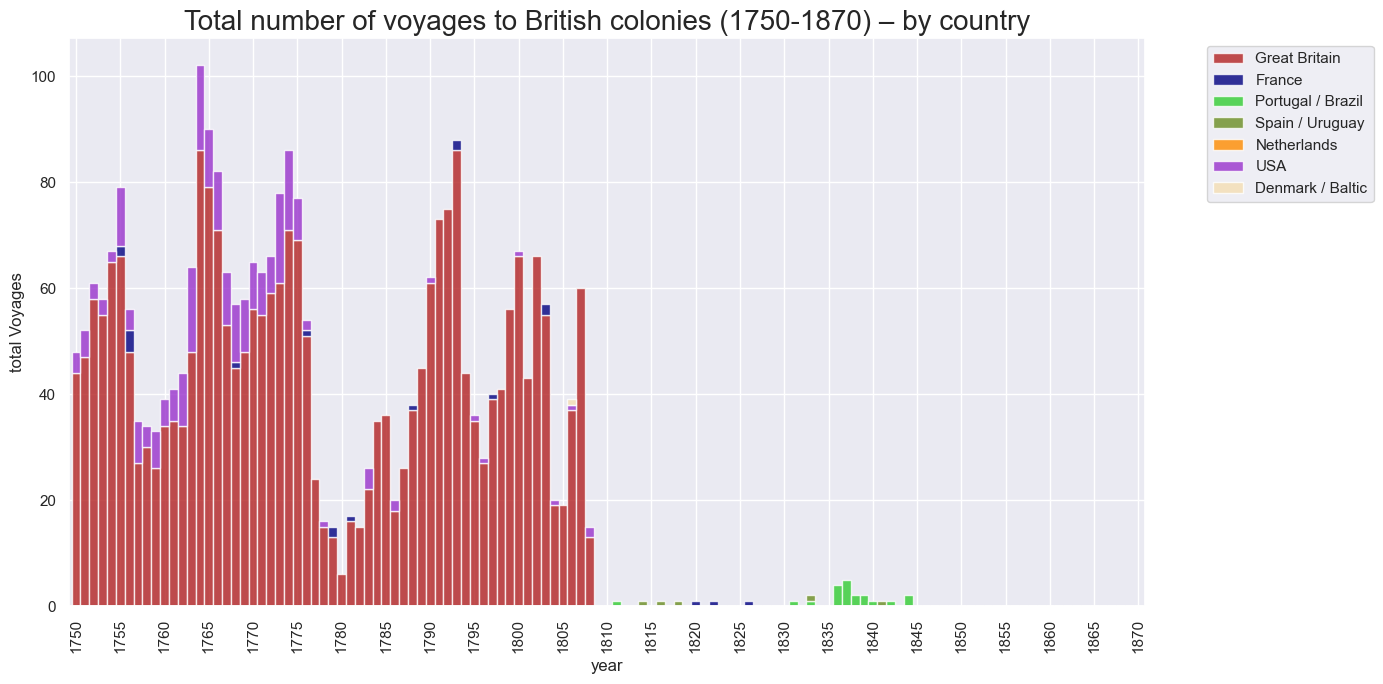

In [47]:
#total number of voyages to GB colonies per year, for each country, 1750-1870, as stacked bar

#order
country_order = [
    "Great Britain",
    "France",
    "Portugal / Brazil",
    "Spain / Uruguay",
    "Netherlands",
    "USA"
]

#voyages to GB colonies by each country
stdb3_gbcol = stdb3[stdb3['colonial_power_sel'] == 'Great Britain']
to_gbcol_per_year = stdb3_gbcol.groupby(["year", "country"]).size().unstack(fill_value=0)

#ensure full year range (1750–1870), fill missing with 0
years = range(1750, 1871)
to_gbcol_per_year = to_gbcol_per_year.reindex(years, fill_value=0)

#reorder columns
all_countries = list(to_gbcol_per_year.columns)
extra_countries = [c for c in all_countries if c not in country_order]
ordered_cols = country_order + extra_countries
to_gbcol_per_year = to_gbcol_per_year.reindex(columns=ordered_cols, fill_value=0)

#plot stacked bar (totals)
plt.figure(figsize=(14, 7))
to_gbcol_per_year.plot(
    kind="bar",
    stacked=True,
    color=[color_mapping.get(c, color_mapping["Other"]) for c in to_gbcol_per_year.columns],
    alpha=0.8,
    width=1.0,
    ax=plt.gca()
)

plt.ylabel("total Voyages")
plt.xlabel("year")
plt.xticks(ticks=range(0, len(to_gbcol_per_year.index), 5), labels=to_gbcol_per_year.index[::5], rotation=90)
plt.title("Total number of voyages to British colonies (1750-1870) – by country", size=20)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


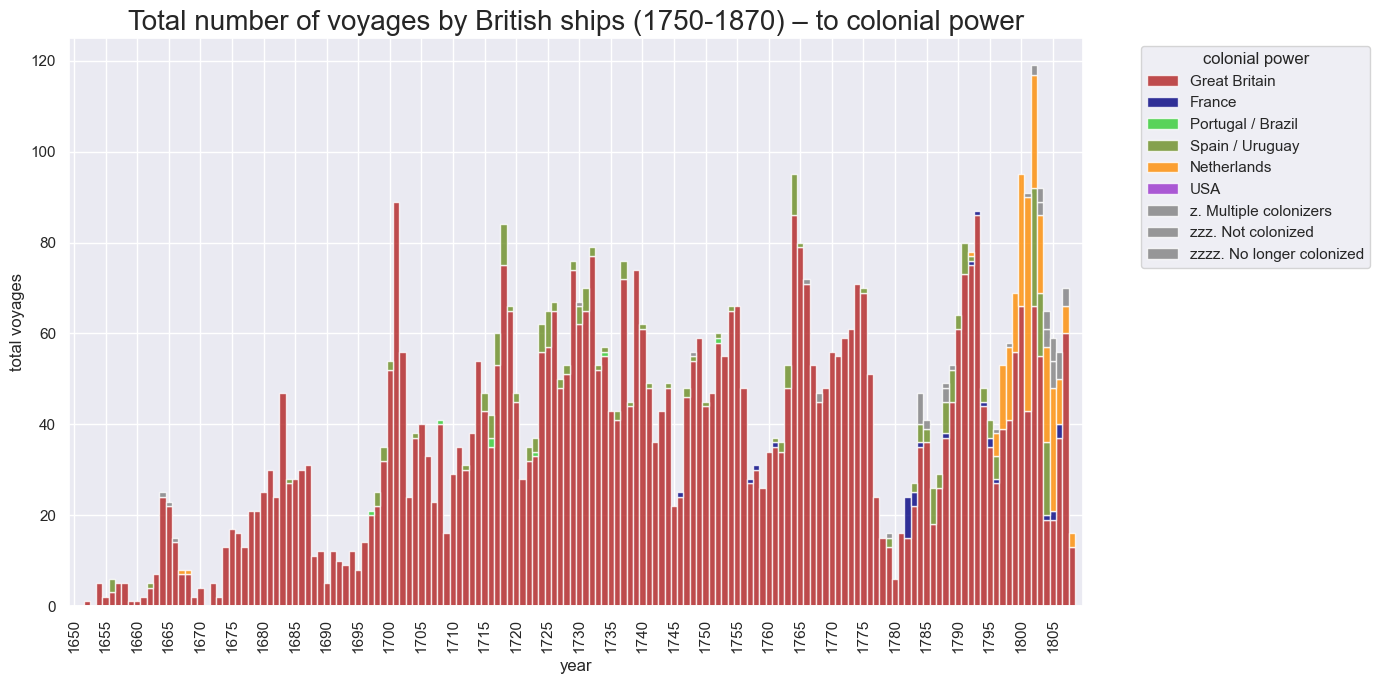

In [48]:
#total number of voyages by British ships to each colonial power, 1750-1870, as stacked bar

#order
power_order = [
    "Great Britain",
    "France",
    "Portugal / Brazil",
    "Spain / Uruguay",
    "Netherlands",
    "USA"
]

#select only British vessels
stdb3_gbships = stdb3[stdb3['country'] == "Great Britain"]

#group by year & colonial_power_sel
destinations_per_year = stdb3_gbships.groupby(["year", "colonial_power_sel"]).size().unstack(fill_value=0)

#ensure full year range (1750–1870), fill missing with 0
years = range(1650, 1810)
destinations_per_year = destinations_per_year.reindex(years, fill_value=0)

#reorder columns
all_powers = list(destinations_per_year.columns)
extra_powers = [c for c in all_powers if c not in power_order]
ordered_cols = power_order + extra_powers
destinations_per_year = destinations_per_year.reindex(columns=ordered_cols, fill_value=0)

#plot stacked bar (totals)
plt.figure(figsize=(14, 7))
destinations_per_year.plot(
    kind="bar",
    stacked=True,
    color=[color_mapping.get(c, color_mapping["Other"]) for c in destinations_per_year.columns],
    alpha=0.8,
    width=1.0,
    ax=plt.gca()
)

plt.ylabel("total voyages")
plt.xlabel("year")
plt.xticks(ticks=range(0, len(destinations_per_year.index), 5), labels=destinations_per_year.index[::5], rotation=90)
plt.title("Total number of voyages by British ships (1750-1870) – to colonial power", size=20)
plt.legend(title="colonial power", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


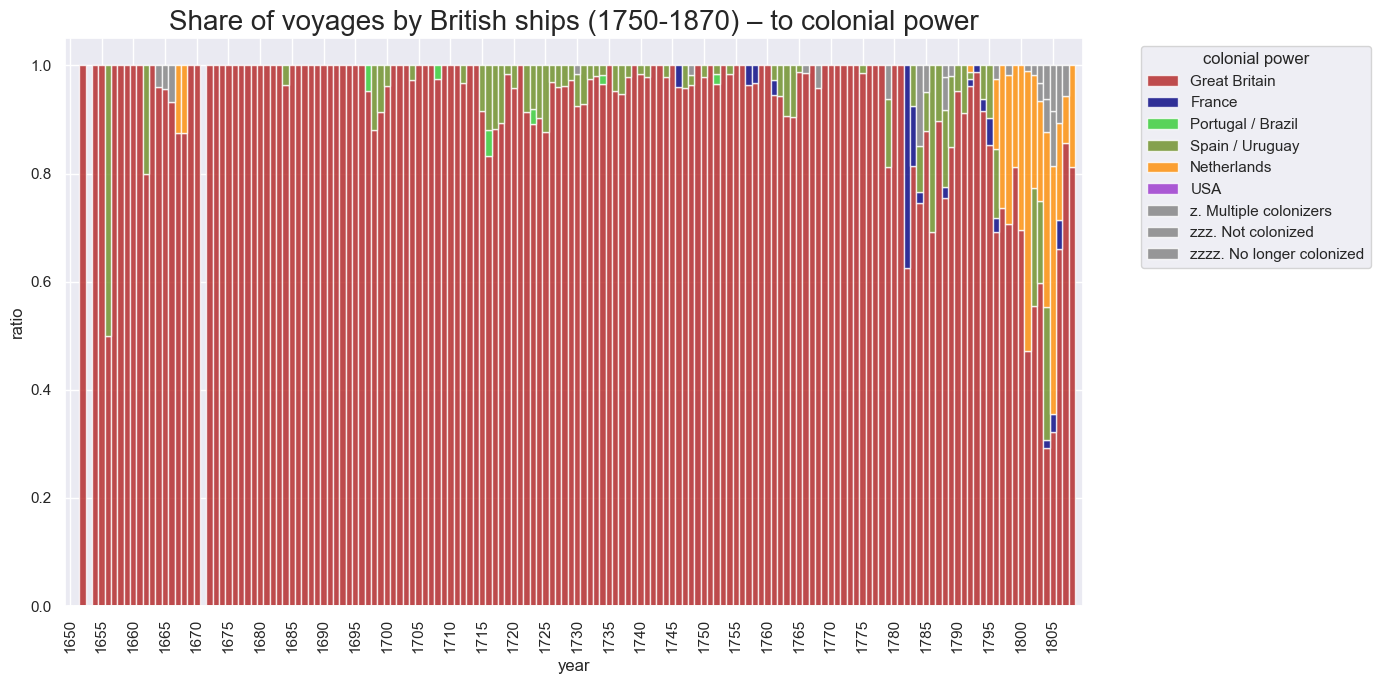

In [49]:
#share of voyages by British ships to each colonial power, 1750-1870, as stacked bar (ratios)

#order
power_order = [
    "Great Britain",
    "France",
    "Portugal / Brazil",
    "Spain / Uruguay",
    "Netherlands",
    "USA"
]

#select only British vessels
stdb3_gbships = stdb3[stdb3['country'] == "Great Britain"]

#group by year & colonial_power_sel
destinations_per_year = stdb3_gbships.groupby(["year", "colonial_power_sel"]).size().unstack(fill_value=0)

#ensure full year range (1750–1870), fill missing with 0
years = range(1650, 1810)
destinations_per_year = destinations_per_year.reindex(years, fill_value=0)

#convert to ratios
destinations_ratio_per_year = destinations_per_year.div(destinations_per_year.sum(axis=1), axis=0).fillna(0)

#reorder columns
all_powers = list(destinations_ratio_per_year.columns)
extra_powers = [c for c in all_powers if c not in power_order]
ordered_cols = power_order + extra_powers
destinations_ratio_per_year = destinations_ratio_per_year.reindex(columns=ordered_cols, fill_value=0)

#plot stacked bar (ratios)
fig, ax = plt.subplots(figsize=(14, 7))
destinations_ratio_per_year.plot(
    kind="bar",
    stacked=True,
    color=[color_mapping.get(c, color_mapping["Other"]) for c in destinations_ratio_per_year.columns],
    alpha=0.8,
    width=1.0,
    ax=ax
)

plt.ylabel("ratio")
plt.xlabel("year")
plt.xticks(ticks=range(0, len(destinations_per_year.index), 5), labels=destinations_per_year.index[::5], rotation=90)
plt.title("Share of voyages by British ships (1750-1870) – to colonial power", size=20)
plt.legend(title="colonial power", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [216]:
stdb3_gbships.head(5)

,year,country,number,port_buy,port_sel,port_buy_lng,port_buy_lat,port_sel_lng,port_sel_lat,colonial_power_buy,colonial_power_sel
6287,1663,Great Britain,175.0,"Gold Coast, port unspecified","Barbados, port unspecified",-1.0992,5.19077,-59.6,13.1,Portugal / Brazil,Great Britain
6288,1663,Great Britain,150.0,Ardra,"Barbados, port unspecified",2.2,6.4,-59.6,13.1,zzz. Not colonized,Great Britain
6289,1663,Great Britain,125.0,"Bight of Biafra and Gulf of Guinea Islands, po...","Barbados, port unspecified",7.16667,4.43333,-59.6,13.1,zzz. Not colonized,Great Britain
6290,1663,Great Britain,159.0,Calabar,"Jamaica, port unspecified",8.31667,4.95,-76.8,17.98333,zzz. Not colonized,Great Britain
6291,1663,Great Britain,197.0,Ardra,"Barbados, port unspecified",2.2,6.4,-59.6,13.1,zzz. Not colonized,Great Britain


export as geopackage and grouped by place, year, colonial power

In [ ]:
import geopandas as gpd
import pandas as pd
import os

#output directory
out_dir = data_dir+"journeys_by_british"
os.makedirs(out_dir, exist_ok=True)

#periods
periods = {
    "1650_1700": (1650, 1700),
    "1700_1750": (1700, 1750),
    "1750_1780": (1750, 1780),
    "1780_1790": (1780, 1790),
    "1790_1810": (1790, 1810),
}

#remove missing coords
stdb3_ports = stdb3.dropna(subset=["port_sel_lng", "port_sel_lat"])

#add VOYAGEID as index
stdb3_ports = stdb3_ports.reset_index().rename(columns={"index": "VOYAGEID"})

#convert to GeoDataFrame
gdf = gpd.GeoDataFrame(
    stdb3_ports,
    geometry=gpd.points_from_xy(stdb3_ports["port_sel_lng"], stdb3_ports["port_sel_lat"]),
    crs="EPSG:4326"
)

for name, (start, end) in periods.items():
    #filter to period
    subset = gdf[(gdf["year"] >= start) & (gdf["year"] < end)]
    if subset.empty:
        continue

    #voyages
    out_path = os.path.join(out_dir, f"voyages_{name}.gpkg")
    subset.to_file(out_path, layer="voyages", driver="GPKG")

    #grouped
    agg_dict = {"VOYAGEID": "count"}
    if "number" in subset.columns:
        agg_dict["number"] = "sum"

    grouped = (
        subset.groupby(["port_sel", "port_sel_lng", "port_sel_lat", "colonial_power_sel"])
        .agg(agg_dict)
        .rename(columns={"VOYAGEID": "voyages_count", "number": "number_sum"})
        .reset_index()
    )

    #convert to GeoDataFrame
    gdf_grouped = gpd.GeoDataFrame(
        grouped,
        geometry=gpd.points_from_xy(grouped["port_sel_lng"], grouped["port_sel_lat"]),
        crs="EPSG:4326"
    )
    
    #save
    out_grouped = os.path.join(out_dir, f"voyages_grouped_{name}.gpkg")
    gdf_grouped.to_file(out_grouped, layer="voyages_grouped", driver="GPKG")
